# Notebook 03: Wildfire Clustering Around Lake Tahoe

**Obstacle-Aware Clustering for Geographic Data**

This notebook applies the obstacle-aware k-Means algorithm to real-world wildfire occurrence data around Lake Tahoe and tests when and why each component of the framework adds value.

### Main Findings

1. **The framework provides real improvement over standard k-Means** when attributes are integrated with appropriately tuned weights (mean arc-length span: -26%, $\sigma_a$: +133%).
2. **The arc-length parameter $s$ does most of its work for fires close to the obstacle.** On the full basin (where most fires are 2-10 km from shore), $s$ contributes only 2% of the geographic coherence improvement. Restricted to fires within 1 km of the lake, that contribution jumps to 26%.
3. **The algorithm's effectiveness scales with the fraction of points near the obstacle.** This is a finding about *when* obstacle-aware clustering matters, not just whether it works.

### Structure

The analysis runs in two tiers:

- **Tier 1 (Spatial Only)** compares standard k-Means against the obstacle-aware algorithm using only geographic and arc-length features. This isolates the effect of the arc-length parameter $s$ without attributes mixed in.
- **Tier 2 (Spatial + Attributes)** adds fire size and cause type to the feature vector, using the full distance metric. Three follow-up diagnostics in Tier 2 characterize where the framework's value actually comes from — including the by-chance attribute baseline, isolating the effect of $s$, and the near-shore subset comparison.

### The Weighted Distance Metric

The obstacle-aware k-Means algorithm uses a composite distance that combines three domains. Between any two feature vectors $\mathbf{x}$ and $\mathbf{x}'$:

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \cdot \|\text{geo} - \text{geo}'\|^2 + \beta^2 \cdot d_s(s, s')^2 + \gamma^2 \cdot \|\text{attr} - \text{attr}'\|^2$$

where:
- $\alpha$ controls the weight on **geographic** distance (Euclidean in scaled $x, y$)
- $\beta$ controls the weight on **arc-length** distance (loop-aware distance in $s$, the normalized position along the lake boundary)
- $\gamma$ controls the weight on **attribute** distance (Euclidean in fire size and cause type)

By tuning these weights, the algorithm can trade off among spatial proximity, obstacle-aware connectivity, and behavioral similarity.

### The Objective Function

To find the best weights, we minimize a composite objective:

$$J = \bar{\rho} + (1 - \sigma_a)$$

where $\bar{\rho}$ is the mean within-cluster distortion (lower = tighter clusters) and $\sigma_a \in [0,1]$ is the fraction of statistically significant pairwise attribute differences between clusters (higher = more distinct clusters). In Tier 1 where there are no attributes, $\sigma_a = 0$ and $J$ simplifies to $\bar{\rho}$. In Tier 2, we minimize $J$ over a grid of $(\beta, \gamma)$ values to find the optimal weighting.

---

## 1. Setup

In [1]:
import os
# Prevent sklearn/KMeans from spawning parallel threads on Windows
# (also suppresses a harmless OpenMP warning)
os.environ['OMP_NUM_THREADS'] = '1'

# Suppress scipy.integrate accuracy warnings that surface during
# arc-length calculations on the spline boundary
import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings('ignore', category=IntegrationWarning)

#Standard packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# For polygon clipping during boundary cleanup and basin filtering
from shapely.geometry import Polygon as ShapelyPolygon

# Database access for the FPA FOD wildfire data
import sqlite3

# Caching utilities so expensive cells only run once
import json as json_lib
import pickle
from pathlib import Path

# sklearn baselines and preprocessing
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Optimization tools
from scipy.optimize import dual_annealing

# Our custom package
from obstacle_clustering import (
    SplineBoundary, ObstacleKMeans,
    loop_aware_distance,
    optimize_weights, attribute_separation,
)
from obstacle_clustering.optimization import objective_function

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,           # base size — affects everything
    'axes.titlesize': 16,      # subplot titles
    'axes.labelsize': 14,      # x and y axis labels
    'xtick.labelsize': 12,     # x tick numbers
    'ytick.labelsize': 12,     # y tick numbers
    'legend.fontsize': 12,
    'figure.titlesize': 18,    # suptitle
})

# Consistent cluster colors across all plots in this notebook
CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# --- Caching ---
# Expensive cells (simulated annealing, objective surfaces) save their
# results so reruns are instant. Delete a file in cache_dir to force a rerun.
cache_dir = Path('../data/cached')
cache_dir.mkdir(parents=True, exist_ok=True)


def cached_or_run(cache_path, compute_fn, force_rerun=False):
    """Load from cache if it exists, otherwise run compute_fn and save."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_rerun:
        print(f'Loading cached: {cache_path.name}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print(f'Computing (will cache to {cache_path.name})...')
    result = compute_fn()
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    return result

# --- Helpers ---

def map_labels_to_reference(labels, reference_labels, k):
    """Map cluster labels so colors/IDs align with a reference labeling.
    
    For each new label, finds the reference label it overlaps with most.
    Greedy assignment ensures no two new labels map to the same reference.
    Useful for keeping cluster colors consistent across plots and for
    aligning per-cluster columns in comparison tables.
    """
    overlap = np.zeros((k, k), dtype=int)
    for i in range(k):
        for j in range(k):
            overlap[i, j] = np.sum((labels == i) & (reference_labels == j))
    
    mapping = {}
    used = set()
    sort_order = np.argsort(-overlap.max(axis=1))
    for i in sort_order:
        for j in np.argsort(-overlap[i]):
            if j not in used:
                mapping[i] = j
                used.add(j)
                break
    return mapping

## 2. Loading the Boundary Data

Two boundaries play distinct roles in this analysis. The **Lake Tahoe shoreline** (from Notebook 02) defines the obstacle and the arc-length parameter $s$ -- every fire gets projected onto this curve. The **Tahoe Regional Planning Agency (TRPA) basin polygon** defines our study area. We restrict the analysis to fires that fall inside the TRPA jurisdictional boundary.

### Lake Tahoe Shoreline (Obstacle)

In [2]:
# Load boundary from Notebook 02
boundary_df = pd.read_csv('../data/boundaries/lake_tahoe_boundary.csv')
lon_boundary = boundary_df['longitude'].values
lat_boundary = boundary_df['latitude'].values

# Fit cubic splines to the cleaned boundary coordinates from Notebook 02
boundary = SplineBoundary(x_coords=lon_boundary, y_coords=lat_boundary)

L = boundary.total_arc_length()
print(f'Lake Tahoe boundary: {len(lon_boundary)} vertices')
print(f'Total arc length: {L:.4f} degrees')

# Sample for plotting (reused throughout the notebook)
spline_pts = boundary.sample_boundary(n_points=500)

Lake Tahoe boundary: 269 vertices
Total arc length: 1.2027 degrees


### TRPA Basin (Study Area)

In [3]:
# Load the TRPA basin boundary (defines our study area)
basin_path = Path('../data/raw/trpa_boundary.geojson')
if not basin_path.exists():
    raise FileNotFoundError(
        f'{basin_path} not found. Download the TRPA Boundary GeoJSON from\n'
        f'https://www.tahoeopendata.org/datasets/TRPA::trpa-boundary/about\n'
        f'and place it at this path.'
    )

import json
with open(basin_path) as f:
    basin_geojson = json.load(f)

# Extract the polygon coordinates
basin_coords = basin_geojson['features'][0]['geometry']['coordinates'][0]
basin_polygon = ShapelyPolygon(basin_coords)

print(f'TRPA basin: {len(basin_coords)} vertices ')  

TRPA basin: 3387 vertices 


## 3. Loading Wildfire Data

The [Fire Program Analysis Fire-Occurrence Database (FPA FOD)](https://www.fs.usda.gov/rds/archive/catalog/RDS-2013-0009.6) is a national database of wildfires reported in the United States from 1992 to 2020. We query the SQLite database for fires within a bounding box around Lake Tahoe (roughly 38.85°–39.35° N, 120.25°–119.85° W), which captures fires on the shoreline and in the surrounding basin.

**Important**: The FPA FOD SQLite file is not included in this repository due to its size (~2 GB). To reproduce this analysis:
1. Download `FPA_FOD_20221014.sqlite` from the [USFS Research Data Archive](https://www.fs.usda.gov/rds/archive/catalog/RDS-2013-0009.6)
2. Rename to `fires.sqlite` and place in the `data/raw/` directory

In [4]:
# Connect to the FPA FOD SQLite database
db_path = '../data/raw/fires.sqlite'  

# Bounding box around the TRPA basin to limit the SQL pull
# (the actual basin polygon filter happens below after loading)
query = """
    SELECT LATITUDE, LONGITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
           NWCG_CAUSE_CLASSIFICATION, FIRE_YEAR, DISCOVERY_DOY
    FROM Fires
    WHERE LATITUDE BETWEEN 38.85 AND 39.35
      AND LONGITUDE BETWEEN -120.25 AND -119.85
"""

with sqlite3.connect(db_path) as conn:
    fires_raw = pd.read_sql_query(query, conn)

# Filter to fires inside the TRPA basin polygon
from shapely.geometry import Point
fires_raw['_pt'] = fires_raw.apply(
    lambda row: Point(row['LONGITUDE'], row['LATITUDE']), axis=1
)
fires_raw['in_basin'] = fires_raw['_pt'].apply(basin_polygon.contains)

n_before = len(fires_raw)
fires_raw = fires_raw[fires_raw['in_basin']].drop(columns=['_pt', 'in_basin']).copy()
n_after = len(fires_raw)

print(f'Fires in SQL bounding box: {n_before}')
print(f'Fires within TRPA basin:   {n_after}')
print(f'Year range: {fires_raw["FIRE_YEAR"].min()}-{fires_raw["FIRE_YEAR"].max()}')
print(f'\nCause breakdown:')
print(fires_raw['NWCG_GENERAL_CAUSE'].value_counts().to_string())

Fires in SQL bounding box: 1888
Fires within TRPA basin:   1376
Year range: 1992-2020

Cause breakdown:
NWCG_GENERAL_CAUSE
Recreation and ceremony                       391
Missing data/not specified/undetermined       308
Natural                                       204
Smoking                                       166
Arson/incendiarism                             85
Misuse of fire by a minor                      71
Debris and open burning                        65
Equipment and vehicle use                      36
Power generation/transmission/distribution     35
Fireworks                                      10
Other causes                                    5


## 4. Data Cleaning and Feature Engineering

We prepare the data for clustering in four steps:

1. **Filter out "Missing data/not specified/undetermined" cause entries** -- without a known cause, these fires can't be encoded as natural vs. human
2. **Encode cause as binary**: Natural (lightning) vs. Human (all other known causes)
3. **Project each fire onto the lake boundary** to calculate its arc-length parameter $s$
4. **Normalize the geographic coordinates and fire size** to put them on comparable scales with $s$ 

In [5]:
# --- Step 1: Filter out missing cause data ---
fires = fires_raw[
    fires_raw['NWCG_GENERAL_CAUSE'] != 'Missing data/not specified/undetermined'
].copy()
print(f'Fires after filtering missing cause: {len(fires)}')

# --- Step 2: Encode cause as binary ---
# Encode NWCG cause as binary: 0 = Natural, 1 = Human-caused
fires['cause_binary'] = (fires['NWCG_GENERAL_CAUSE'] != 'Natural').astype(int)

print(f'\nCause classification:')
print(f"  Natural (lightning): {(fires['cause_binary'] == 0).sum()}")
print(f"  Human-caused:        {(fires['cause_binary'] == 1).sum()}")

print(f'\nFire size (acres):')
print(f"  Min:    {fires['FIRE_SIZE'].min():.4f}")
print(f"  Median: {fires['FIRE_SIZE'].median():.2f}")
print(f"  Mean:   {fires['FIRE_SIZE'].mean():.2f}")
print(f"  Max:    {fires['FIRE_SIZE'].max():.2f}")

Fires after filtering missing cause: 1068

Cause classification:
  Natural (lightning): 204
  Human-caused:        864

Fire size (acres):
  Min:    0.0100
  Median: 0.10
  Mean:   10.39
  Max:    4222.00


In [6]:
# --- Step 3: Project each fire onto the lake boundary ---
# This may take several minutes on first run; subsequent runs load from cache.
# NOTE: If you change the fire bounding box (Cell 6) or re-clean the
# boundary (Notebook 02), delete data/cached/fire_projections.pkl to
# force a recompute.

def project_all_fires():
    print('Projecting fire locations onto lake boundary...')
    lons = fires['LONGITUDE'].values
    lats = fires['LATITUDE'].values
    n = len(fires)

    t_arr = np.zeros(n)
    s_arr = np.zeros(n)
    for idx in range(n):
        if idx % 200 == 0:
            print(f'  {idx}/{n} ({100*idx/n:.0f}%)')
        t_arr[idx], s_arr[idx] = boundary.project_point(lons[idx], lats[idx])
    return t_arr, s_arr


t_values, s_values = cached_or_run(
    cache_dir / 'fire_projections.pkl',
    project_all_fires,
)

fires['t_param'] = t_values
fires['s_param'] = s_values

print(f'Projection complete: {len(fires)} fires projected')
print(f's range: [{fires["s_param"].min():.4f}, {fires["s_param"].max():.4f}]')

Loading cached: fire_projections.pkl
Projection complete: 1068 fires projected
s range: [0.0069, 0.9980]


### Fire Size Distribution

Fire sizes in the FPA FOD span many orders of magnitude (from tiny spot fires to thousands of acres). We compare the raw distribution to a log-transformed version to motivate using the log scale in clustering.

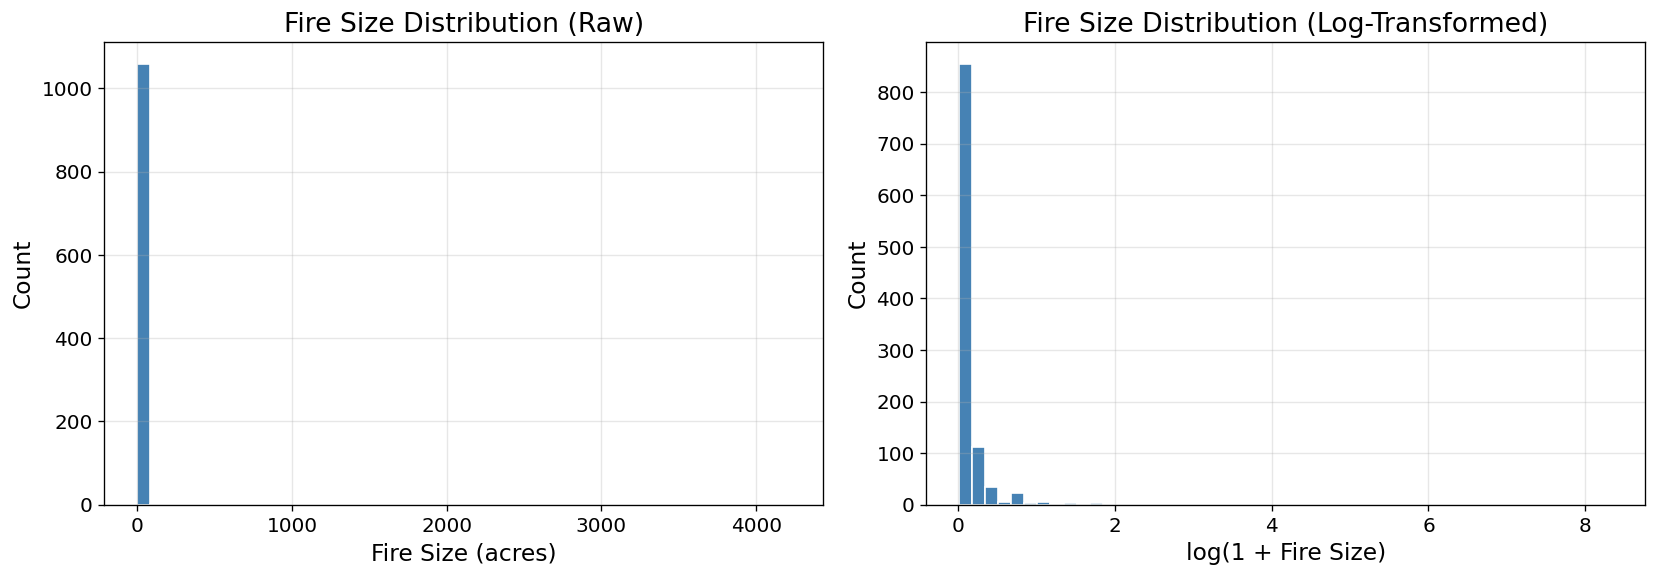

In [7]:
# Compare raw vs. log-transformed fire size distributions
# log1p = log(1+x) handles fires recorded with size 0 cleanly
fires['fire_size_log'] = np.log1p(fires['FIRE_SIZE'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
ax = axes[0]
ax.hist(fires['FIRE_SIZE'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Fire Size (acres)')
ax.set_ylabel('Count')
ax.set_title('Fire Size Distribution (Raw)')
ax.grid(True, alpha=0.3)

# Log-transformed
ax = axes[1]
ax.hist(fires['fire_size_log'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('log(1 + Fire Size)')
ax.set_ylabel('Count')
ax.set_title('Fire Size Distribution (Log-Transformed)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# --- Step 4: Normalize features ---
# Geographic coordinates: Min-Max scale to [0, 1]
scaler_xy = MinMaxScaler()
xy_scaled = scaler_xy.fit_transform(fires[['LONGITUDE', 'LATITUDE']].values)

# Fire size (log): Min-Max scale to [0, 1]
scaler_size = MinMaxScaler()
fire_size_scaled = scaler_size.fit_transform(fires[['fire_size_log']].values)

# s is already in [0, 1]
# cause_binary is already 0 or 1

# Assemble feature matrix: [x_scaled, y_scaled, s, fire_size_scaled, cause_binary]
X = np.column_stack([
    xy_scaled,                          # columns 0, 1: geographic
    fires['s_param'].values,            # column 2: arc-length
    fire_size_scaled.ravel(),           # column 3: fire size (log + normalized)
    fires['cause_binary'].values        # column 4: cause type
])

# Feature names in order -- used downstream for plot labels and attribute indexing
feature_names = ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

# This full feature matrix gets used in Tier 2.
# Tier 1 will use only X[:, :3] (geography + arc-length, no attributes)

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {feature_names}')
print(f'\nFirst 5 rows:')
print(np.array2string(X[:5], precision=4, suppress_small=True))

Feature matrix shape: (1068, 5)
Features: ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

First 5 rows:
[[0.1654 0.3369 0.026  0.0102 1.    ]
 [0.5317 0.1934 0.8678 0.0102 1.    ]
 [0.3648 0.0065 0.9344 0.0256 0.    ]
 [0.2032 0.6204 0.1603 0.0102 1.    ]
 [0.5456 0.191  0.8635 0.0102 1.    ]]


In [9]:
# Save processed fire data as a CSV 
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

processed_path = processed_dir / 'tahoe_fires_processed.csv'
fires.to_csv(processed_path, index=False)

print(f'Saved {len(fires)} fires to {processed_path}')
print('Columns: LONGITUDE, LATITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,')
print('         FIRE_YEAR, DISCOVERY_DOY, cause_binary, t_param, s_param, fire_size_log')

Saved 1068 fires to ..\data\processed\tahoe_fires_processed.csv
Columns: LONGITUDE, LATITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
         FIRE_YEAR, DISCOVERY_DOY, cause_binary, t_param, s_param, fire_size_log


## 5. Visualizing the Raw Data

Before clustering, we look at the spatial distribution of fires around the lake. The left panel colors each fire by cause (natural vs. human), and the right panel colors by arc-length position $s$ around the perimeter.

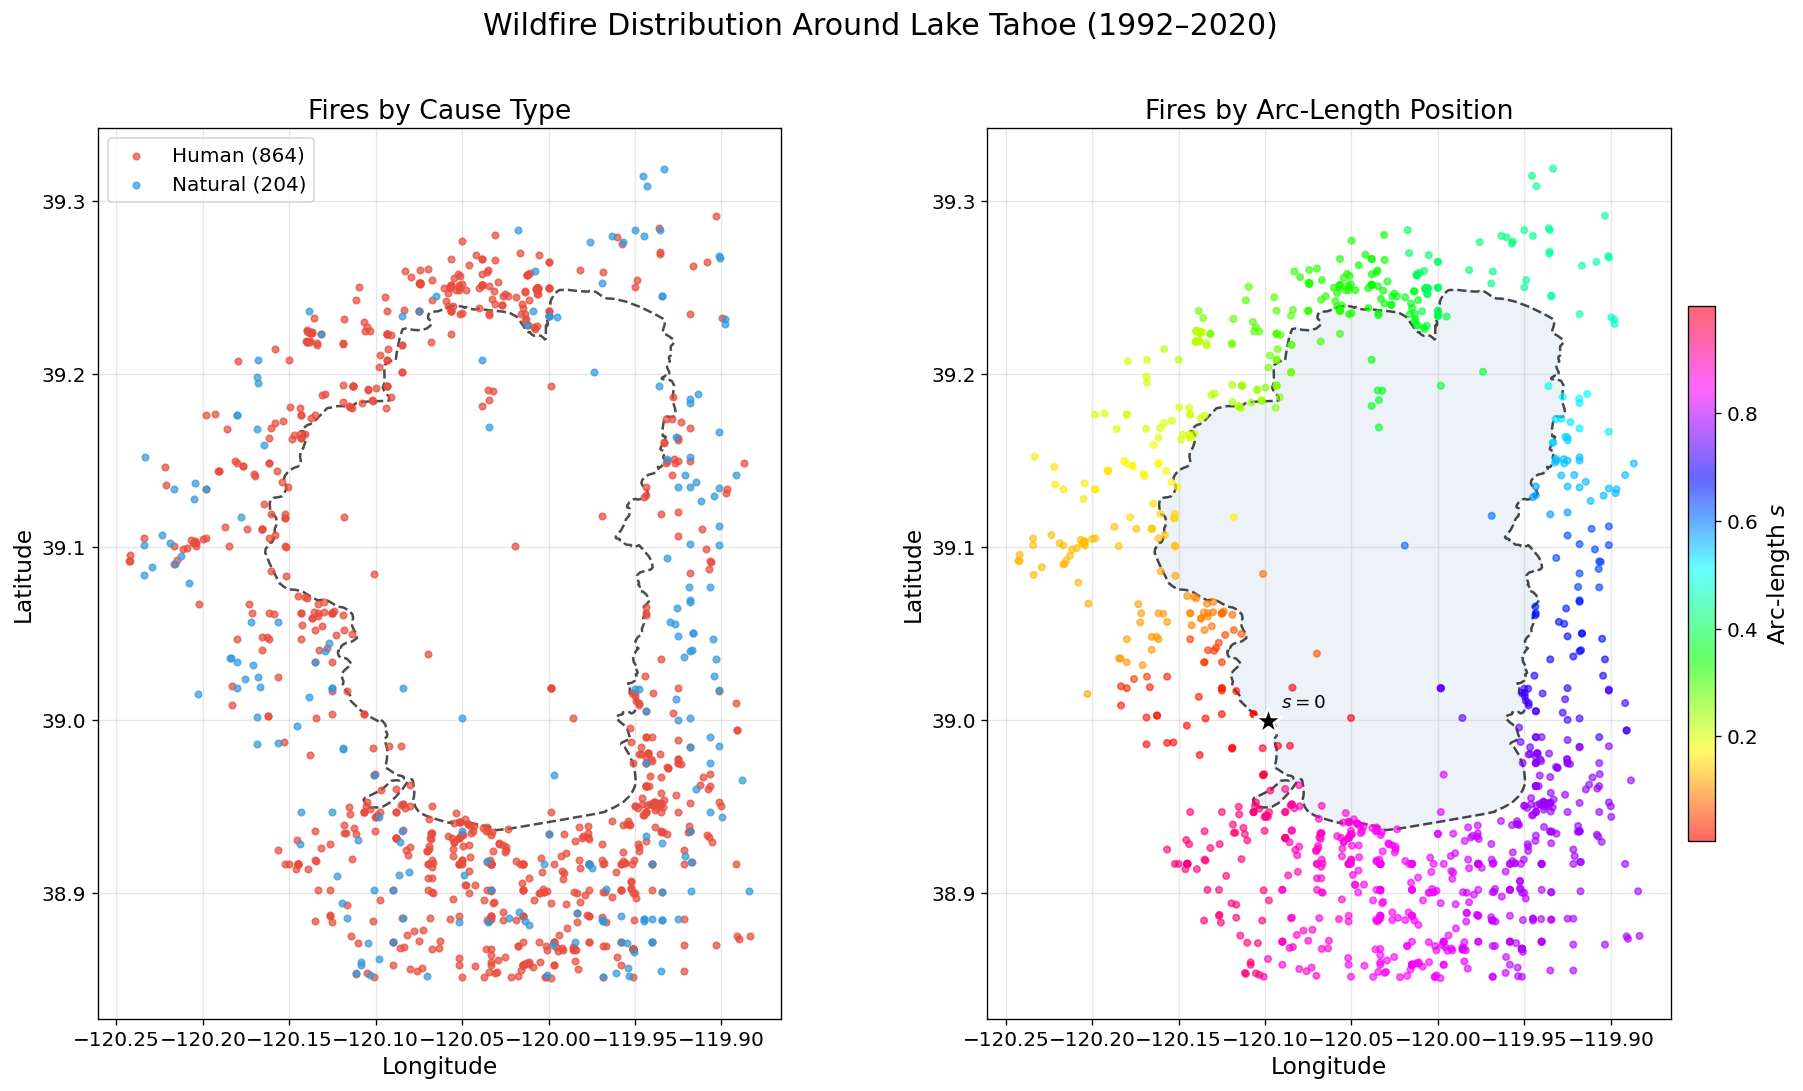

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# --- Left panel: by cause ---
ax = axes[0]
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0., color='steelblue')

natural = fires[fires['cause_binary'] == 0]
human = fires[fires['cause_binary'] == 1]

# Plot human first, natural on top 
ax.scatter(human['LONGITUDE'], human['LATITUDE'],
           c='#e74c3c', s=15, alpha=0.7, label=f'Human ({len(human)})', zorder=3)
ax.scatter(natural['LONGITUDE'], natural['LATITUDE'],
           c='#3498db', s=15, alpha=0.7, label=f'Natural ({len(natural)})', zorder=3)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Fires by Cause Type')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Right panel: by arc-length position ---
# HSV colormap wraps around so s=0 and s=1 show the same color
ax = axes[1]
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

scatter = ax.scatter(fires['LONGITUDE'], fires['LATITUDE'],
                     c=fires['s_param'], cmap='hsv', s=15, alpha=0.6, zorder=3)
plt.colorbar(scatter, ax=ax, label='Arc-length $s$', shrink=0.6, aspect=20, pad=0.02)

# Mark the boundary's start position (s = 0)
s0_xy = boundary.evaluate(boundary.t_range()[0])
ax.scatter(s0_xy[0], s0_xy[1], marker='*', s=300, color='black',
           edgecolors='white', linewidth=1.5, zorder=5)
ax.annotate('$s = 0$', xy=(s0_xy[0], s0_xy[1]), xytext=(8, 8),
            textcoords='offset points', fontsize=11, fontweight='bold')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Fires by Arc-Length Position')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

year_min = fires['FIRE_YEAR'].min()
year_max = fires['FIRE_YEAR'].max()
plt.suptitle(f'Wildfire Distribution Around Lake Tahoe ({year_min}–{year_max})', y=1.01)
plt.tight_layout()
plt.show()

---

# TIER 1: Spatial-Only Comparison

**Goal**: Isolate the effect of the arc-length parameter $s$ on clustering quality, without attributes.

In Tier 1, all methods use $\gamma = 0$ (no attribute component). The distance metric simplifies to:

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \cdot \|\text{geo} - \text{geo}'\|^2 + \beta^2 \cdot d_s(s, s')^2$$

We compare two approaches:
1. **Standard k-Means** on $(x, y)$ -- baseline, ignoring the obstacle
2. **Obstacle-aware k-Means** on $(x, y, s)$ with $\alpha = \beta = 1$ -- equal spatial weights

A sensitivity check verifies that the choice of $\beta$ does not meaningfully change the clustering on this dataset.

## 6. Spatial-Only Feature Matrix

For Tier 1 we slice off the first three columns of the full feature matrix to build a spatial-only matrix `X_spatial`. The same matrix gets used in both the baseline standard k-Means and the obstacle-aware k-Means in this tier.

In [11]:
# Tier 1 uses only the spatial features (no attributes)
X_spatial = X[:, :3]

print(f'Tier 1 feature matrix shape: {X_spatial.shape}')
print(f'Features: {feature_names[:3]}')

Tier 1 feature matrix shape: (1068, 3)
Features: ['x_scaled', 'y_scaled', 's']


## 7. Choosing the Number of Clusters (elbow method)

Before running any clustering, we use the elbow method to choose $k$. The method runs k-Means for a range of $k$ values and plots the inertia (within-cluster sum of squared distances) for each. A good $k$ is where the curve bends; adding more clusters beyond that point gives diminishing returns.

We use standard k-Means here since the elbow method is about the data's natural cluster structure, not about the choice of distance metric.

c:\Users\mpp24\anaconda3\envs\obstacle-clustering\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


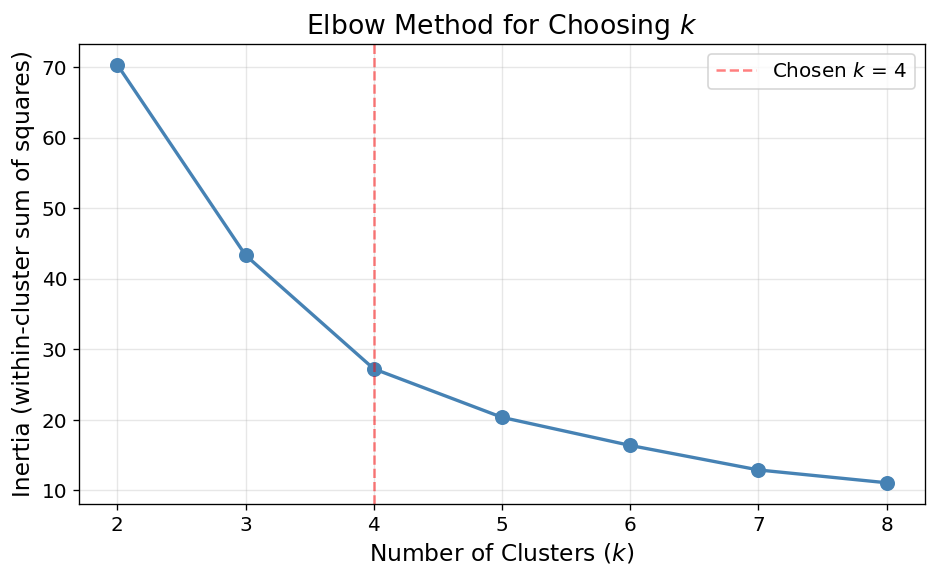

Inertia by k:
  k=2: 70.3290
  k=3: 43.3322
  k=4: 27.2352
  k=5: 20.3613
  k=6: 16.3810
  k=7: 12.9070
  k=8: 11.0922


In [12]:
# Elbow method: test k = 2 through 8
k_range = range(2, 9)
inertias = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    km.fit(xy_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=8)

# Mark the chosen k
ax.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Chosen $k$ = 4')

ax.set_xlabel('Number of Clusters ($k$)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Method for Choosing $k$')
ax.set_xticks(list(k_range))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the values for reference
print('Inertia by k:')
for k_test, inertia in zip(k_range, inertias):
    print(f'  k={k_test}: {inertia:.4f}')

The inertia curve flattens noticeably after $k = 4$, suggesting four clusters fit the spatial structure well. We use $k = 4$ throughout the rest of the notebook.

## 8. Standard k-Means Baseline

As a baseline, we run standard k-Means using only the geographic coordinates $(x, y)$. This treats the space as unobstructed and ignores fire attributes entirely. The result gives us a comparison point for the obstacle-aware version in Tier 1.

In [59]:
# Standard k-Means on (x, y) only
k = 4
kmeans_standard = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_standard = kmeans_standard.fit_predict(xy_scaled)

print(f'Standard k-Means converged in {kmeans_standard.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    n = np.sum(labels_standard == i)
    print(f'  Cluster {i+1}: {n} fires')

Standard k-Means converged in 10 iterations

Cluster sizes:
  Cluster 1: 305 fires
  Cluster 2: 230 fires
  Cluster 3: 223 fires
  Cluster 4: 310 fires


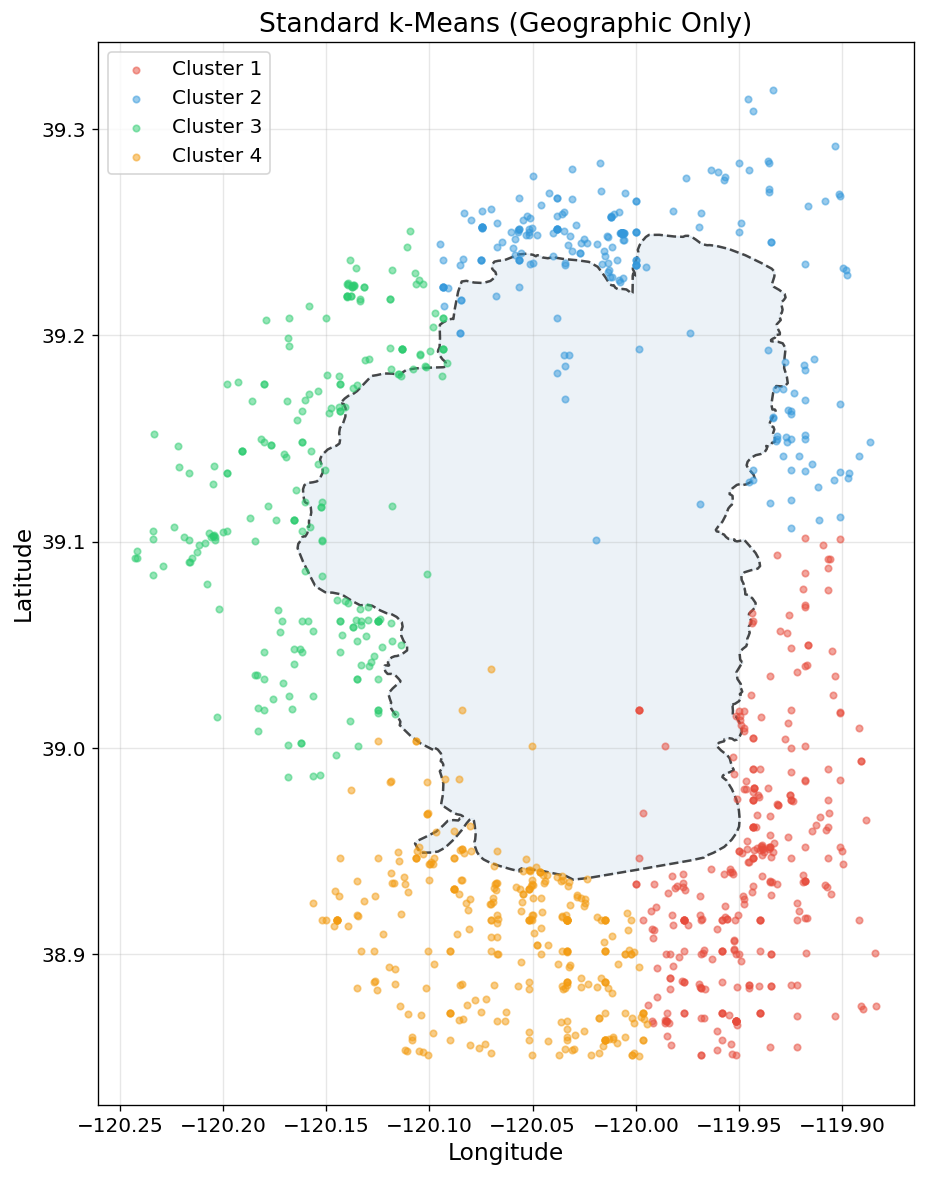

In [60]:
# Plot standard k-Means results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_standard == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Standard k-Means (Geographic Only)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Obstacle-Aware k-Means 

We run the obstacle-aware algorithm with $\alpha = \beta = 1$, giving geographic distance and arc-length distance equal influence on cluster assignments. The next section examines whether varying $\beta$ changes the result, which informs whether tuning the balance matters for this dataset.

In [61]:
# Obstacle-aware k-Means: spatial only, equal weights (alpha = beta = 1)
model_t1_equal = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,    # no attributes
    random_state=42, n_attr=0
)
model_t1_equal.fit(X_spatial, t_data=fires['t_param'].values)
labels_t1_equal = model_t1_equal.labels_

print(f'Tier 1 equal weights: converged in {model_t1_equal.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t1_equal == i)} fires')

Tier 1 equal weights: converged in 13 iterations

Cluster sizes:
  Cluster 1: 305 fires
  Cluster 2: 236 fires
  Cluster 3: 216 fires
  Cluster 4: 311 fires


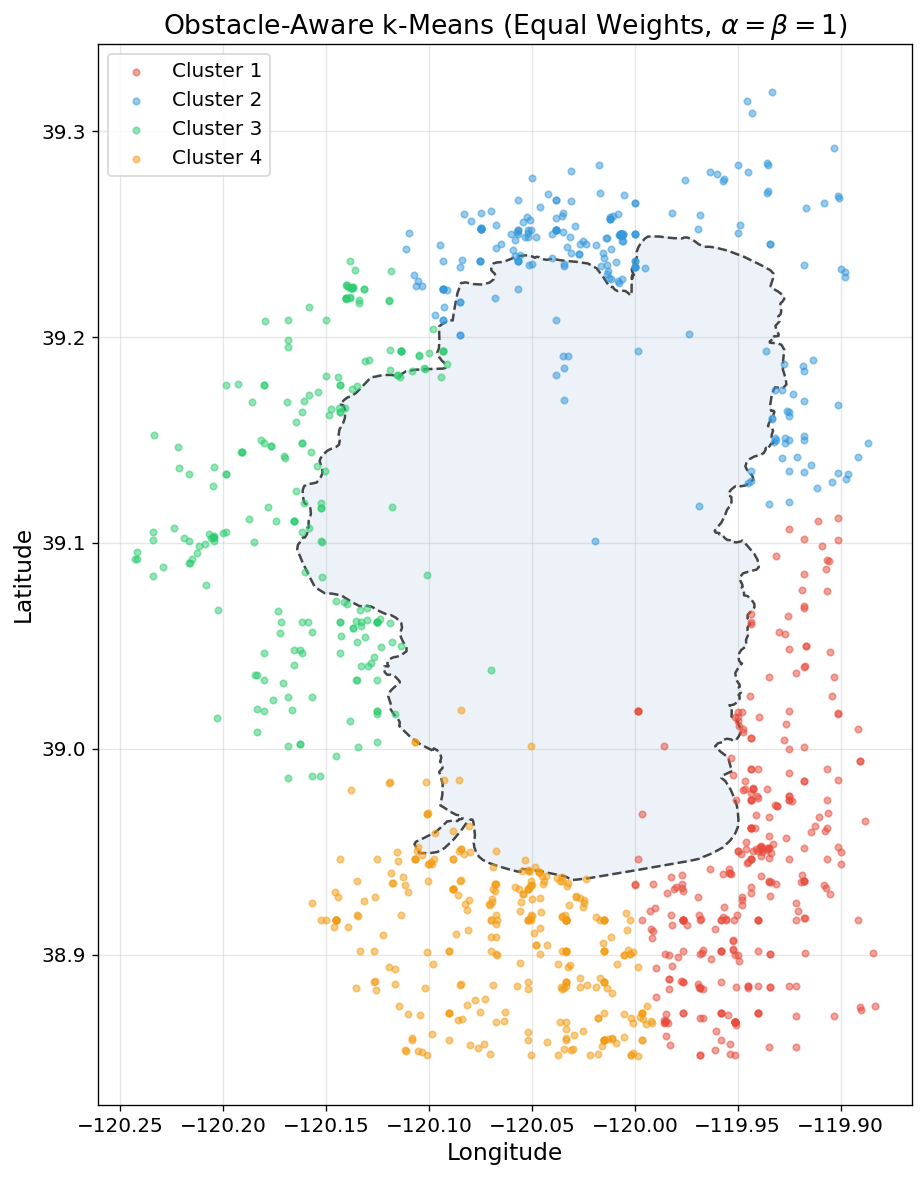

In [62]:
# Plot Tier 1 equal-weights clustering results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_t1_equal == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(r'Obstacle-Aware k-Means (Equal Weights, $\alpha = \beta = 1$)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Sensitivity to $\beta$

Before settling on $\beta = 1$, we check whether the choice of $\beta$ meaningfully changes the clustering. The objective function $J = \bar{\rho} + (1 - \sigma_a)$ simplifies in Tier 1 because there are no attribute features, so $\sigma_a = 0$ and $J$ reduces to the mean within-cluster distortion $\bar{\rho}$ -- a measure of how spread out the points are around their centroids. We calculate $J(\beta)$ across a grid of values and look at the spread.

In [63]:
# Compute J(beta) across a grid for the sensitivity curve 
def compute_tier1_beta_sweep():
    beta_grid = np.linspace(0.1, 2.0, 10)
    J_values = np.array([
        objective_function(
            (1.0, b, 0.0),
            X_spatial, fires['t_param'].values, boundary,
            k=k, n_attr=0, attr_indices=[], random_state=42
        )
        for b in beta_grid
    ])
    return beta_grid, J_values


beta_grid_t1, J_grid_t1 = cached_or_run(
    cache_dir / 'tier1_beta_sweep.pkl',
    compute_tier1_beta_sweep,
)

print('beta -> J:')
for b, j in zip(beta_grid_t1, J_grid_t1):
    print(f'  beta = {b:.2f}:  J = {j:.4f}')
print(f'\nRange: {J_grid_t1.max() - J_grid_t1.min():.4f}')

Loading cached: tier1_beta_sweep.pkl
beta -> J:
  beta = 0.10:  J = 1.0310
  beta = 0.31:  J = 1.0310
  beta = 0.52:  J = 1.0309
  beta = 0.73:  J = 1.0307
  beta = 0.94:  J = 1.0307
  beta = 1.16:  J = 1.0307
  beta = 1.37:  J = 1.0377
  beta = 1.58:  J = 1.0378
  beta = 1.79:  J = 1.0378
  beta = 2.00:  J = 1.0308

Range: 0.0070


$J$ varies by less than 1% across $\beta \in [0.1, 2.0]$. The choice of $\beta$ doesn't meaningfully change the clustering on this dataset. We use $\beta = 1$ for the comparison in the next section.

## 11. Tier 1 Comparison

We compare standard k-Means against obstacle-aware k-Means with $\beta = 1$. The side-by-side plot shows where the cluster boundaries differ; the quantitative comparison measures how well each method respects the lake.

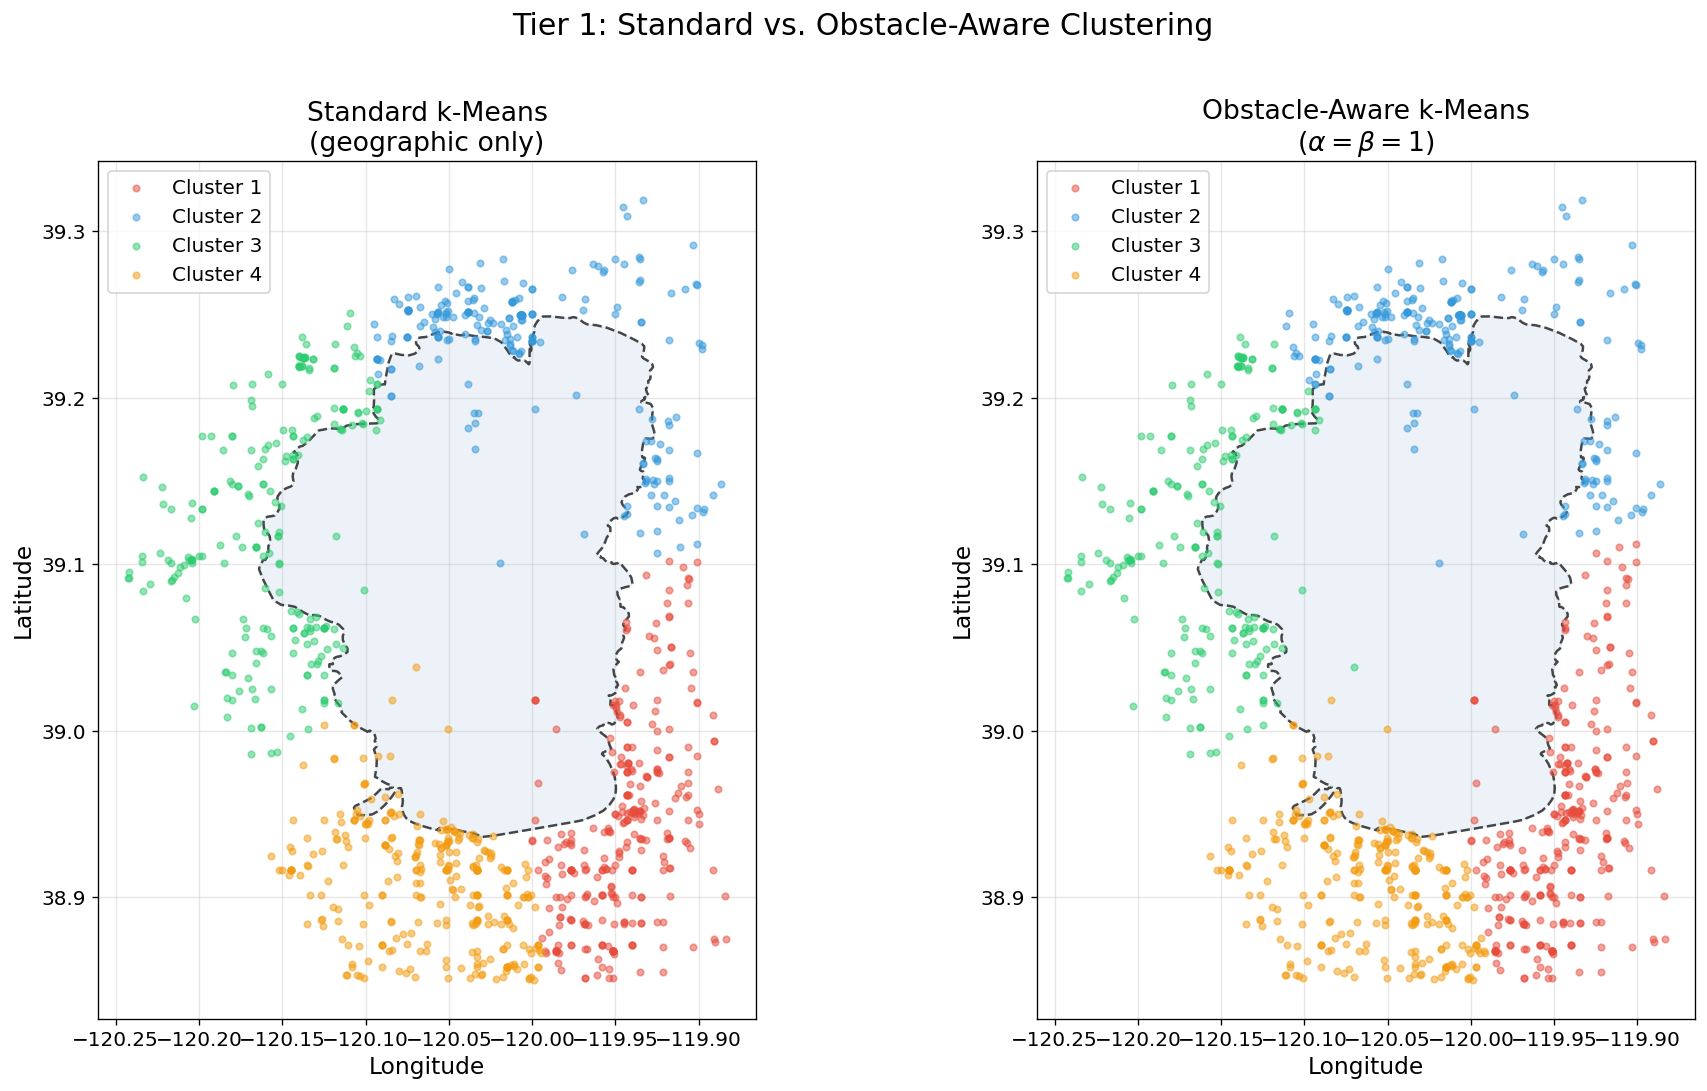

In [64]:
# Side-by-side: standard k-Means vs. obstacle-aware k-Means

# Map obstacle-aware cluster labels to standard k-Means labels
# so cluster colors stay consistent across the two panels
oa_to_std = map_labels_to_reference(labels_t1_equal, labels_standard, k)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

panel_data = [
    (labels_standard, lambda lbl: lbl, 'Standard k-Means\n(geographic only)'),
    (labels_t1_equal, lambda lbl: oa_to_std[lbl],
     r'Obstacle-Aware k-Means' + '\n' + r'($\alpha = \beta = 1$)'),
]

for ax, (labels, color_fn, title) in zip(axes, panel_data):
    # Boundary first
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.5, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
    # Fires
    for cluster_id in range(k):
        mask = labels == cluster_id
        ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[color_fn(cluster_id)], s=15, alpha=0.5,
                   label=f'Cluster {color_fn(cluster_id)+1}', zorder=3)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Tier 1: Standard vs. Obstacle-Aware Clustering', y=1.01)
plt.tight_layout()
plt.show()

### Quantitative Comparison

We measure how well each method respects the lake boundary using **mean arc-length span** -- the average, across clusters, of the smallest arc on the boundary that contains all of that cluster's projected fire locations. This metric evaluates the cluster labels using the same calculation regardless of how the labels were produced, which is what makes it a fair comparison between standard and obstacle-aware k-Means. A lower span means each cluster's fires sit on a more compact stretch of shoreline.

In [65]:
def arc_length_span(s_values):
    """Smallest arc on [0,1] that contains all s values (handles wraparound)."""
    if len(s_values) <= 1:
        return 0.0
    s_sorted = np.sort(s_values % 1.0)
    gaps = np.diff(s_sorted)
    wrap_gap = (1.0 - s_sorted[-1]) + s_sorted[0]
    all_gaps = np.append(gaps, wrap_gap)
    return 1.0 - np.max(all_gaps)


# Reuse oa_to_std mapping for cluster labels
methods = [
    ('Standard k-Means', labels_standard, lambda lbl: lbl),
    ('Obstacle-Aware (β = 1)', labels_t1_equal, lambda lbl: oa_to_std[lbl]),
]

rows = []
for name, labels, color_fn in methods:
    spans_by_mapped_id = {}
    for raw_cluster_id in range(k):
        mapped_id = color_fn(raw_cluster_id)
        spans_by_mapped_id[mapped_id] = arc_length_span(
            fires['s_param'].values[labels == raw_cluster_id]
        )
    row = {f'Cluster {c+1}': spans_by_mapped_id[c] for c in range(k)}
    row['Mean'] = np.mean(list(spans_by_mapped_id.values()))
    row['Method'] = name
    rows.append(row)

comparison_t1 = pd.DataFrame(rows).set_index('Method')

# Render as a styled table 
styled_t1 = (
    comparison_t1.style
    .format('{:.4f}')
    .set_caption('Tier 1: Arc-length span by cluster')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: left;'},
    ])
    .highlight_min(subset=['Mean'], color='#e8f5e9')
)

styled_t1

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Mean
Method,,,,,
Standard k-Means,0.1977,0.3536,0.2754,0.2331,0.2650
Obstacle-Aware (β = 1),0.1965,0.3361,0.2725,0.1850,0.2475


The obstacle-aware method tightens the mean arc-length span from 0.265 to 0.247 -- a small 7% reduction. Most of the improvement comes from Cluster 4 (0.233 → 0.185). Clusters 1 and 3 are nearly unchanged, consistent with the visual comparison: standard k-Means already separates most fires reasonably well based on geography alone, and the arc-length parameter only reshapes assignments at a few cluster boundaries.

This is consistent with the sensitivity analysis in the previous section: $\beta$ doesn't change the clustering much because most fires are far enough from the lake that geographic distance and arc-length distance largely agree on cluster assignments. The obstacle-aware algorithm produces a slightly tighter clustering, but the effect is small for this dataset.

---

# TIER 2: Spatial + Attribute Comparison

**Goal**: Show that the framework extends to incorporate fire attributes (size and cause), creating clusters that are both spatially coherent and behaviorally distinct.

In Tier 2, the full distance metric is used:

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \cdot \|\text{geo} - \text{geo}'\|^2 + \beta^2 \cdot d_s(s, s')^2 + \gamma^2 \cdot \|\text{attr} - \text{attr}'\|^2$$

The objective function $J = \bar{\rho} + (1 - \sigma_a)$ now includes the attribute separation $\sigma_a$, which measures whether clusters differ significantly in fire size and cause type. We compare three approaches:

1. **Standard k-Means** on $(x, y, \text{fire size}, \text{cause})$ -- baseline with attributes but no arc-length
2. **Obstacle-aware k-Means** with $\alpha = \beta = \gamma = 1$ -- equal weights across all three domains
3. **Obstacle-aware k-Means** with $\alpha = 1$ and optimized $(\beta, \gamma)$ -- tuned with simulated annealing

### Constraint on $\gamma$

We constrain $\gamma \in [0, 1]$ so that $\gamma \leq \alpha$, which keeps attributes from outweighing spatial structure in the clustering. Without this constraint, the optimizer pushes $\gamma$ much higher than $\alpha$ to maximize attribute separation, at the expense of geographic coherence.

## 13. Standard k-Means Baseline

As the Tier 2 baseline, we run standard k-Means on the full feature matrix $(x, y, \text{fire size}, \text{cause})$ -- geographic coordinates plus attributes, but no arc-length component. This is the baseline comparison point for the obstacle-aware version with attributes: it tells us how much (if anything) adding $s$ improves clustering when attribute features are already pulling on cluster assignments.

In [66]:
# Standard k-Means baseline for Tier 2: (x, y, fire_size, cause) -- no s
# We slice off column 2 (s) from the full feature matrix
X_t2_std = np.column_stack([
    X[:, :2],       # x, y
    X[:, 3:],       # fire_size, cause
])

kmeans_t2_std = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_t2_std = kmeans_t2_std.fit_predict(X_t2_std)

print(f'Standard k-Means (Tier 2): converged in {kmeans_t2_std.n_iter_} iterations')
print('\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t2_std == i)} fires')

# Compute attribute separation for the comparison table later
sigma_t2_std, _ = attribute_separation(X, labels_t2_std, k, attr_indices=[3, 4])

Standard k-Means (Tier 2): converged in 6 iterations

Cluster sizes:
  Cluster 1: 184 fires
  Cluster 2: 204 fires
  Cluster 3: 491 fires
  Cluster 4: 189 fires


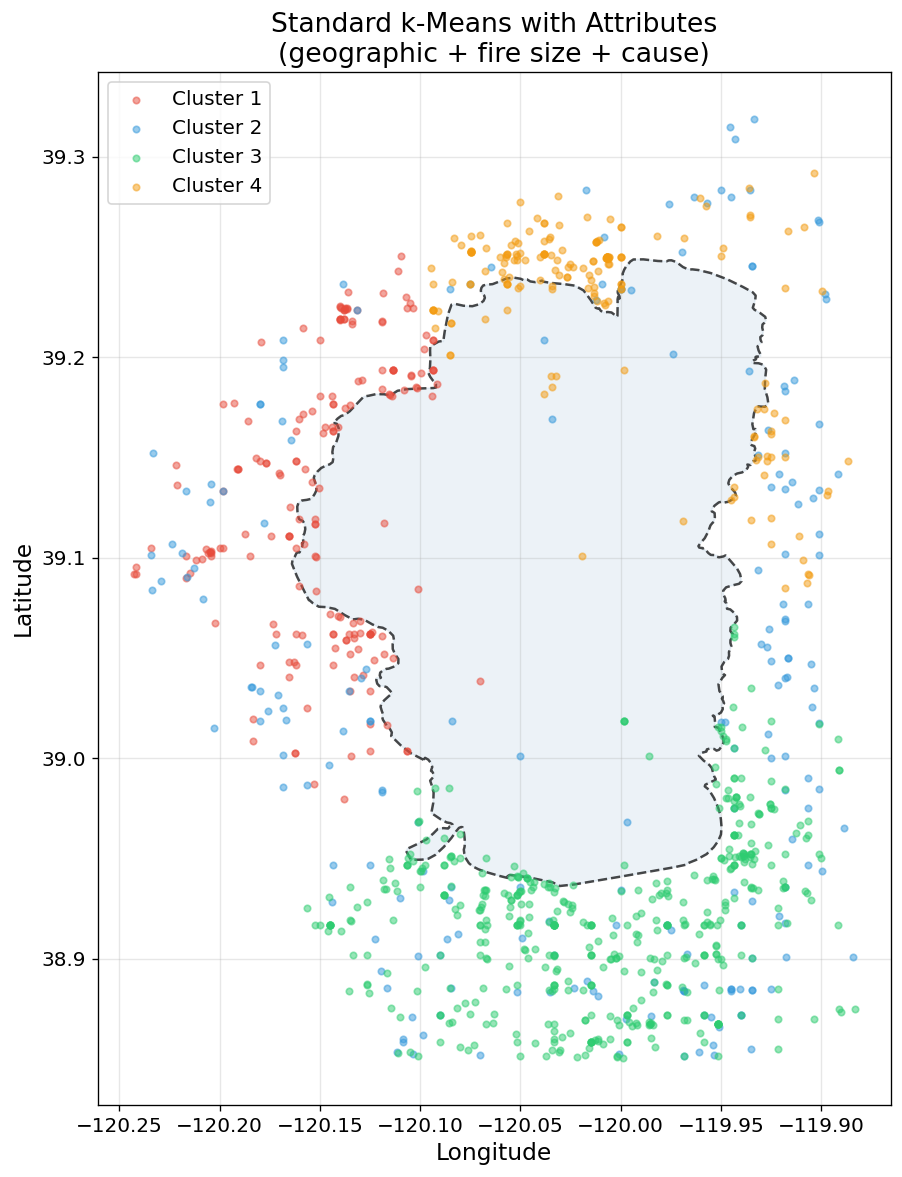

In [67]:
# Plot Tier 2 standard k-Means results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_t2_std == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Standard k-Means with Attributes\n(geographic + fire size + cause)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Obstacle-Aware k-Means (Equal Weights)

We run the full obstacle-aware algorithm with $\alpha = \beta = \gamma = 1$, giving geography, arc-length, and attributes equal influence on cluster assignments. The next section will tune $(\beta, \gamma)$ to find the balance that best separates clusters in attribute space while keeping them spatially coherent.

In [68]:
# Obstacle-aware k-Means: full features, equal weights
model_t2_equal = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=1.0,
    random_state=42, n_attr=2  # 2 attribute features: fire_size, cause
)
model_t2_equal.fit(X, t_data=fires['t_param'].values)
labels_t2_equal = model_t2_equal.labels_

# Calculate attribute separation now; we'll use it in the comparison table
sigma_t2_eq, _ = attribute_separation(X, labels_t2_equal, k, attr_indices=[3, 4])

print(f'Obstacle-aware (Tier 2, equal weights): converged in {model_t2_equal.n_iter_} iterations')
print('\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t2_equal == i)} fires')

Obstacle-aware (Tier 2, equal weights): converged in 5 iterations

Cluster sizes:
  Cluster 1: 512 fires
  Cluster 2: 123 fires
  Cluster 3: 81 fires
  Cluster 4: 352 fires


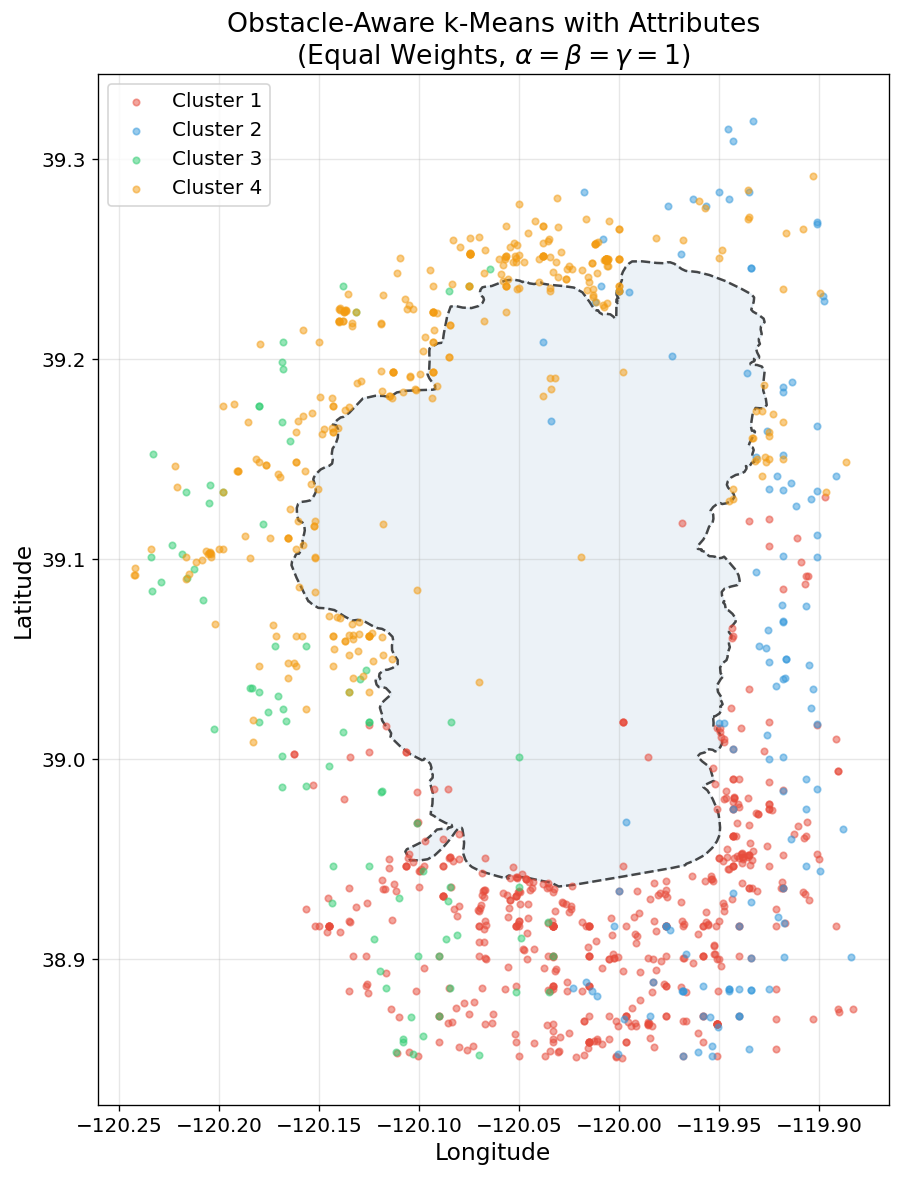

In [69]:
# Plot Tier 2 obstacle-aware (equal weights) clustering results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_t2_equal == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(r'Obstacle-Aware k-Means with Attributes' + '\n' +
             r'(Equal Weights, $\alpha = \beta = \gamma = 1$)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Finding Optimal $\beta$ and $\gamma$

We fix $\alpha = 1$ since only the ratios between weights affect cluster assignments, and search for the best $\beta \in [0, 2]$ and $\gamma \in [0, 1]$. The bound on $\gamma$ enforces the constraint $\gamma \leq \alpha$, keeping attributes from outweighing spatial structure.

We evaluate the objective $J = \bar{\rho} + (1 - \sigma_a)$ on a 15×15 grid and select the minimum. This gives a precise enough optimum (each $\beta$ step is ~0.14, each $\gamma$ step is ~0.07) to balance spatial tightness against attribute differentiation.


**Note**: The first run takes around 60 minutes. Subsequent runs load the cached result instantly.

In [70]:
# Compute J across a grid of (beta, gamma) and select the minimum
def compute_tier2_grid_search():
    print('Computing Tier 2 objective surface and finding grid minimum...')
    n_grid = 15
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    gamma_vals = np.linspace(0.05, 1.0, n_grid)

    J_grid = np.zeros((n_grid, n_grid))
    for i, b in enumerate(beta_vals):
        for j, g in enumerate(gamma_vals):
            J_grid[i, j] = objective_function(
                (1.0, b, g),
                X, fires['t_param'].values, boundary,
                k=k, n_attr=2, attr_indices=[3, 4], random_state=42
            )
        print(f'  beta row {i+1}/{n_grid} complete')
    return beta_vals, gamma_vals, J_grid


beta_grid_t2, gamma_grid_t2, J_surface_t2 = cached_or_run(
    cache_dir / 'tier2_grid_search.pkl',
    compute_tier2_grid_search,
)

# Find minimum on the grid
i_min, j_min = np.unravel_index(J_surface_t2.argmin(), J_surface_t2.shape)
opt_beta_t2 = beta_grid_t2[i_min]
opt_gamma_t2 = gamma_grid_t2[j_min]
opt_J_t2 = J_surface_t2[i_min, j_min]

# Refit the model at the optimum
model_t2_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_t2, gamma=opt_gamma_t2,
    random_state=42, n_attr=2
)
model_t2_opt.fit(X, t_data=fires['t_param'].values)
labels_t2_opt = model_t2_opt.labels_

# Calculate attribute separation for the comparison table
sigma_t2_opt, _ = attribute_separation(X, labels_t2_opt, k, attr_indices=[3, 4])

print(f'\nOptimal beta:  {opt_beta_t2:.4f}')
print(f'Optimal gamma: {opt_gamma_t2:.4f}')
print(f'Optimal J:     {opt_J_t2:.4f}')
print('\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t2_opt == i)} fires')

Loading cached: tier2_grid_search.pkl

Optimal beta:  0.4679
Optimal gamma: 0.3893
Optimal J:     0.4589

Cluster sizes:
  Cluster 1: 485 fires
  Cluster 2: 119 fires
  Cluster 3: 233 fires
  Cluster 4: 231 fires


### Validating the Optimum

We plot the objective surface as a contour map to confirm that the grid optimum sits at a meaningful minimum.

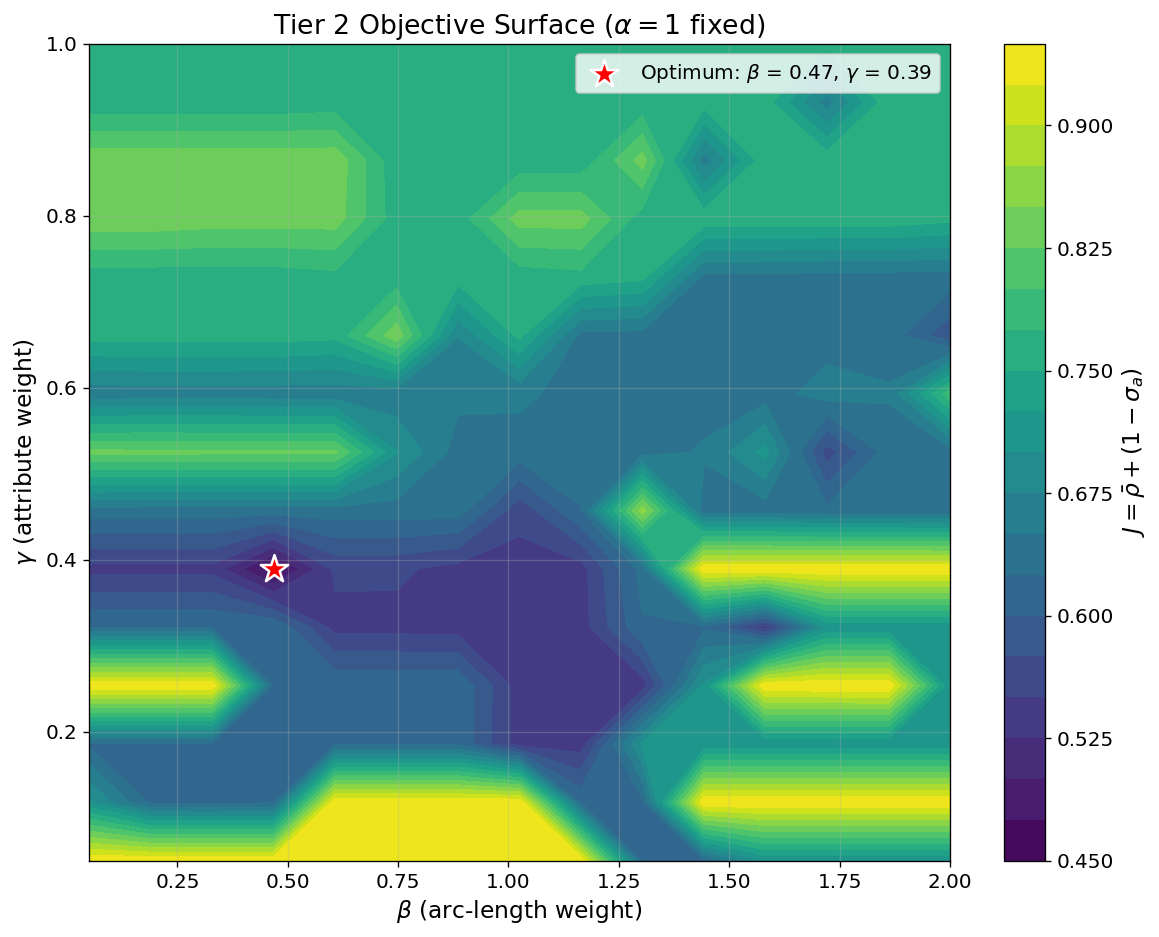

In [71]:
# Contour plot of the objective surface with the optimum marked
fig, ax = plt.subplots(figsize=(10, 8))

# Build a meshgrid for plotting (note: indexing='ij' matches our J_grid layout)
B, G = np.meshgrid(beta_grid_t2, gamma_grid_t2, indexing='ij')

# Filled contours
contour_filled = ax.contourf(B, G, J_surface_t2, levels=20, cmap='viridis')
plt.colorbar(contour_filled, ax=ax, label=r'$J = \bar{\rho} + (1 - \sigma_a)$')

# Optimum
ax.scatter(opt_beta_t2, opt_gamma_t2, marker='*', s=300, color='red',
           edgecolors='white', linewidth=1.5, zorder=5,
           label=f'Optimum: $\\beta$ = {opt_beta_t2:.2f}, $\\gamma$ = {opt_gamma_t2:.2f}')

ax.set_xlabel(r'$\beta$ (arc-length weight)')
ax.set_ylabel(r'$\gamma$ (attribute weight)')
ax.set_title(r'Tier 2 Objective Surface ($\alpha = 1$ fixed)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The objective surface shows a broad low-$J$ valley centered around $\gamma \approx 0.35$, with the grid optimum at $(\beta = 0.47, \gamma = 0.39)$ sitting inside this valley. Extreme attribute weights (very low or very high $\gamma$) produce worse clusterings, confirming that attributes help but shouldn't overwhelm the spatial structure.

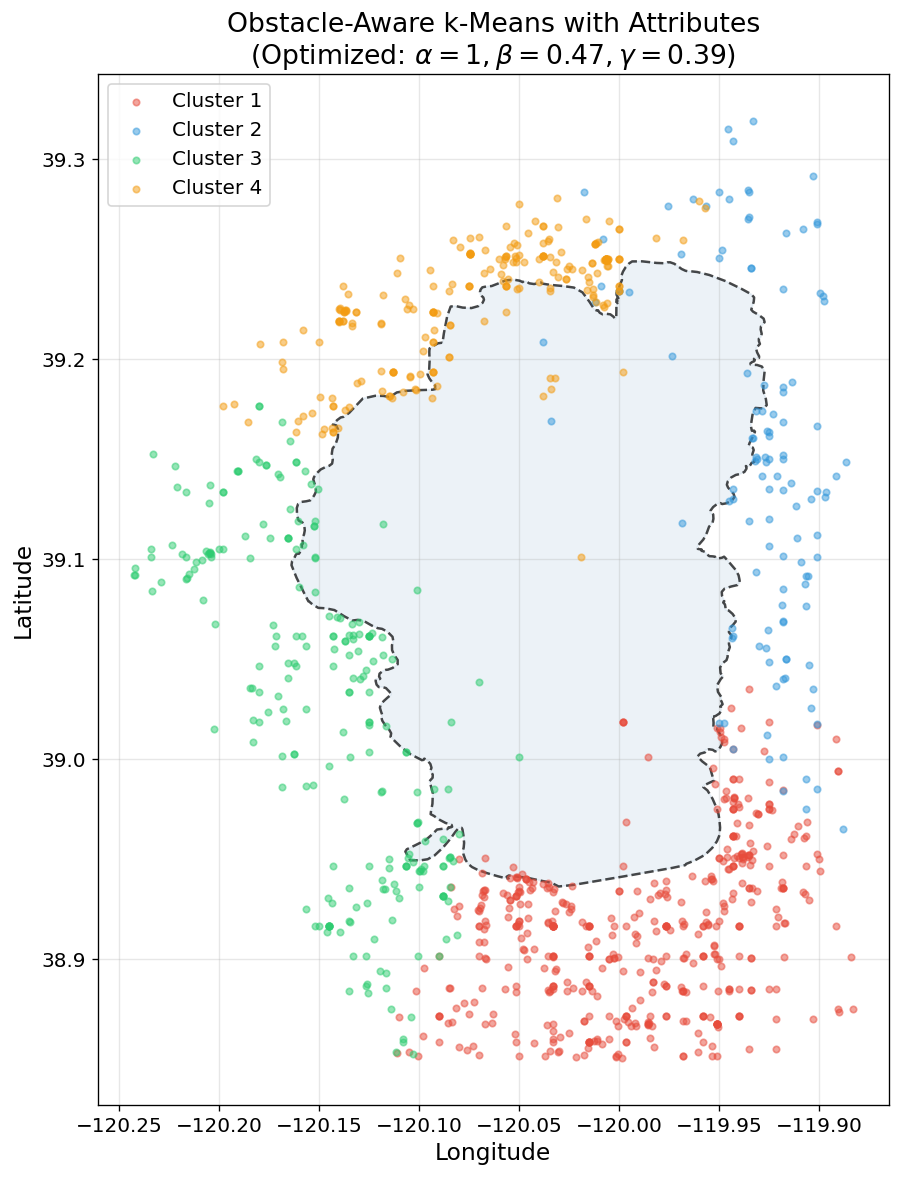

In [72]:
# Plot Tier 2 obstacle-aware (optimized weights) clustering results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_t2_opt == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(r'Obstacle-Aware k-Means with Attributes' + '\n' +
             rf'(Optimized: $\alpha = 1, \beta = {opt_beta_t2:.2f}, \gamma = {opt_gamma_t2:.2f}$)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cluster Profiles

We summarize each cluster's spatial center and attribute composition. The table below gives the centroid location, fire size statistics, and cause breakdown for the four optimized clusters.

In [73]:
# Build a profile table for the optimized clusters
fires['cluster_t2_opt'] = labels_t2_opt

profile_rows = []
for c in range(k):
    cluster = fires[fires['cluster_t2_opt'] == c]
    n = len(cluster)
    n_natural = int((cluster['cause_binary'] == 0).sum())
    n_human = n - n_natural
    profile_rows.append({
        'Cluster': c + 1,
        'n': n,
        'Centroid (lon, lat)': f'({cluster["LONGITUDE"].mean():.3f}, {cluster["LATITUDE"].mean():.3f})',
        'Mean fire size (acres)': cluster['FIRE_SIZE'].mean(),
        'Median fire size (acres)': cluster['FIRE_SIZE'].median(),
        '% Natural': 100 * n_natural / n,
        '% Human': 100 * n_human / n,
    })

profile_t2 = pd.DataFrame(profile_rows).set_index('Cluster')

# Render as a styled table
styled_profile = (
    profile_t2.style
    .format({
        'Mean fire size (acres)': '{:.2f}',
        'Median fire size (acres)': '{:.2f}',
        '% Natural': '{:.1f}',
        '% Human': '{:.1f}',
    })
    .set_caption('Tier 2 Optimized Clusters: Profile Summary')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: center;'},
    ])
)

styled_profile

,n,"Centroid (lon, lat)",Mean fire size (acres),Median fire size (acres),% Natural,% Human
Cluster,,,,,,
1,485,"(-119.991, 38.914)",8.22,0.10,12.2,87.8
2,119,"(-119.930, 39.147)",52.42,0.10,62.2,37.8
3,233,"(-120.147, 39.023)",2.14,0.10,27.0,73.0
4,231,"(-120.069, 39.228)",1.60,0.10,3.5,96.5


The four optimized clusters represent distinct fire regimes:

- **Cluster 1 (south basin)** is the largest cluster, dominated by human-caused fires (87.8%) of moderate average size.
- **Cluster 2 (east-central)** is the smallest but most distinctive cluster: the only one where natural causes are the majority (62.2%), with mean fire size more than six times larger than any other cluster. This likely captures lightning-strike fires in less-developed terrain that grow before suppression.
- **Cluster 3 (west shore)** has the most mixed cause distribution (27% natural) and small mean fire size.
- **Cluster 4 (north basin)** is overwhelmingly human-caused (96.5%), with the smallest mean fire size.

The persistent 0.10-acre median across all clusters reflects the long tail of small reported fires in the FPA FOD database; the differences between clusters show up in the means, where the influence of larger fires is captured.

## 16. Tier 2 Comparison

We compare three methods: standard k-Means, obstacle-aware k-Means with equal weights, and obstacle-aware k-Means with optimized weights. The visual comparison shows how cluster boundaries differ across methods; the quantitative comparison measures geographic coherence and attribute separation.

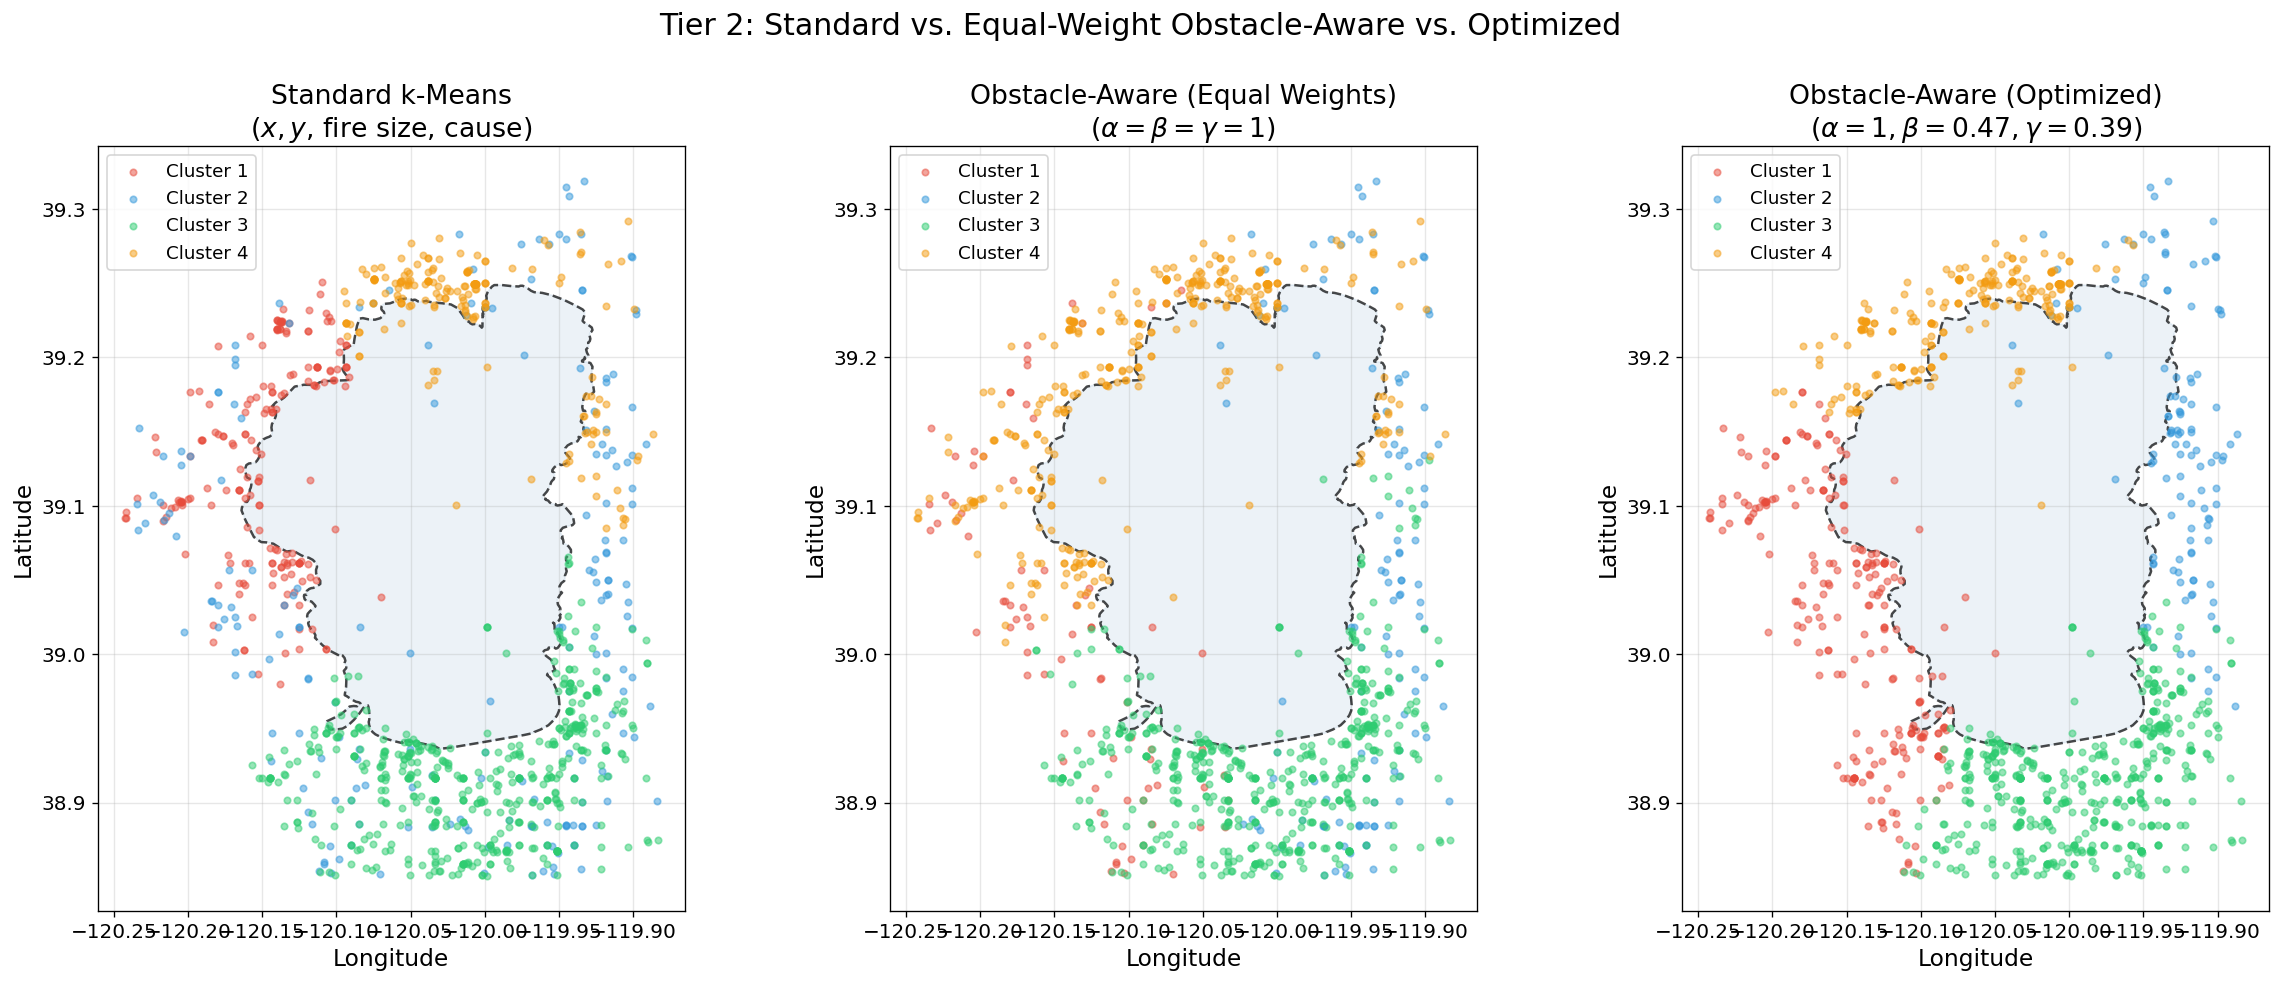

In [74]:
# Side-by-side: standard, equal weights, optimized

# Map both obstacle-aware label sets to the standard k-Means labels
# so cluster colors stay consistent across panels
oa_eq_to_std_t2 = map_labels_to_reference(labels_t2_equal, labels_t2_std, k)
oa_opt_to_std_t2 = map_labels_to_reference(labels_t2_opt, labels_t2_std, k)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

panel_data = [
    (labels_t2_std, lambda lbl: lbl,
     'Standard k-Means\n($x, y$, fire size, cause)'),
    (labels_t2_equal, lambda lbl: oa_eq_to_std_t2[lbl],
     r'Obstacle-Aware (Equal Weights)' + '\n' + r'($\alpha = \beta = \gamma = 1$)'),
    (labels_t2_opt, lambda lbl: oa_opt_to_std_t2[lbl],
     r'Obstacle-Aware (Optimized)' + '\n' +
     rf'($\alpha = 1, \beta = {opt_beta_t2:.2f}, \gamma = {opt_gamma_t2:.2f}$)'),
]

for ax, (labels, color_fn, title) in zip(axes, panel_data):
    # Boundary first
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.5, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

    # Build a reverse mapping so we can iterate by mapped ID order
    raw_for_mapped = {color_fn(raw): raw for raw in range(k)}

    # Fires — drawn in mapped-ID order so the legend is 1, 2, 3, 4
    for mapped_id in range(k):
        raw_id = raw_for_mapped[mapped_id]
        mask = labels == raw_id
        ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[mapped_id], s=15, alpha=0.5,
                   label=f'Cluster {mapped_id + 1}', zorder=3)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.legend(fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Tier 2: Standard vs. Equal-Weight Obstacle-Aware vs. Optimized', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

### Quantitative Comparison

We compare the three methods on two metrics:

- **Mean arc-length span** — the average, across clusters, of the smallest arc on the boundary that contains all of that cluster's projected fire locations. Lower means each cluster sits on a more compact stretch of shoreline. This metric measures geographic coherence.

- **Attribute separation $\sigma_a$** — the fraction of pairwise cluster-vs-cluster attribute differences that are statistically significant. For each attribute (fire size and cause), we run a Kruskal-Wallis omnibus test across all $k$ clusters, then Dunn's post-hoc test on each pair of clusters with Bonferroni correction for multiple comparisons. This metric measures behavioral separation. 

Both are calculated on the cluster labels using the same formula regardless of how the labels were produced, which makes them directly comparable across methods.

In [75]:
methods_t2 = [
    ('Standard k-Means', labels_t2_std, sigma_t2_std),
    ('Obstacle-Aware (Equal Weights)', labels_t2_equal, sigma_t2_eq),
    ('Obstacle-Aware (Optimized)', labels_t2_opt, sigma_t2_opt),
]

rows = []
for name, labels, sigma_a in methods_t2:
    spans = [
        arc_length_span(fires['s_param'].values[labels == c])
        for c in range(k)
    ]
    rows.append({
        'Method': name,
        'Mean arc-length span': np.mean(spans),
        'σ_a': sigma_a,
    })

comparison_t2 = pd.DataFrame(rows).set_index('Method')

styled_t2 = (
    comparison_t2.style
    .format('{:.4f}')
    .set_caption('Tier 2: Comparison across three methods')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: left;'},
    ])
    .highlight_min(subset=['Mean arc-length span'], color='#e8f5e9')
    .highlight_max(subset=['σ_a'], color='#e8f5e9')
)

styled_t2


,Mean arc-length span,σ_a
Method,,
Standard k-Means,0.4739,0.2500
Obstacle-Aware (Equal Weights),0.5073,0.3333
Obstacle-Aware (Optimized),0.3513,0.5833


The optimized obstacle-aware method outperforms both alternatives on both metrics. Mean arc-length span drops from 0.474 (standard) to 0.351 (optimized), a 26% improvement in geographic coherence. Attribute separation $\sigma_a$ more than doubles, from 0.25 to 0.58.

Equal weights performs worse than standard k-Means on geographic coherence (0.507 vs. 0.474). With $\gamma = 1$, the algorithm sacrifices geographic compactness chasing attribute separation, but doesn't push attributes hard enough to produce strong separation either. The optimization corrects this by lowering $\beta$ and $\gamma$ relative to $\alpha$ — letting geography lead while still using attributes enough to roughly double $\sigma_a$ over the standard baseline.

To understand what's driving these results, the following subsections decompose the comparison three ways: how much attribute separation is just baseline geographic correlation, how much of the improvement comes specifically from $s$, and whether $s$'s contribution differs for fires close to the lake versus far from it.

### Baseline: Attribute Separation Without Attributes

The Tier 2 results show that obstacle-aware k-Means with optimized weights produces clusters that are substantially more behaviorally distinct than standard k-Means. But how much of that separation is due to the algorithm, versus the simple fact that attributes correlate with geography in the basin? To check, we calculate $\sigma_a$ on the Tier 1 cluster labels -- clusters formed using only geographic and arc-length features, with no attribute information. Any $\sigma_a$ above zero in this case represents the "by chance" attribute separation that emerges purely from geographic clustering.

In [ ]:
# Calculate σ_a on Tier 1 cluster labels — what attribute separation
# emerges by chance from purely geographic clustering?
sigma_t1_std, _ = attribute_separation(
    X, labels_standard, k, attr_indices=[3, 4]
)
sigma_t1_oa, _ = attribute_separation(
    X, labels_t1_equal, k, attr_indices=[3, 4]
)

baseline_rows = [
    {
        'Method': 'Tier 1 standard k-Means (no attributes used)',
        'σ_a': sigma_t1_std,
    },
    {
        'Method': 'Tier 1 obstacle-aware (β = 1, no attributes used)',
        'σ_a': sigma_t1_oa,
    },
    {
        'Method': 'Tier 2 standard k-Means (attributes used)',
        'σ_a': sigma_t2_std,
    },
    {
        'Method': 'Tier 2 obstacle-aware (equal weights)',
        'σ_a': sigma_t2_eq,
    },
    {
        'Method': 'Tier 2 obstacle-aware (optimized)',
        'σ_a': sigma_t2_opt,
    },
]

baseline_t2 = pd.DataFrame(baseline_rows).set_index('Method')

styled_baseline = (
    baseline_t2.style
    .format('{:.4f}')
    .set_caption('Attribute separation across all methods (Tier 1 and Tier 2)')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: left;'},
    ])
    .highlight_max(subset=['σ_a'], color='#e8f5e9')
)

styled_baseline

,σ_a
Method,
Tier 1 standard k-Means (no attributes used),0.0833
"Tier 1 obstacle-aware (β = 1, no attributes used)",0.0833
Tier 2 standard k-Means (attributes used),0.2500
Tier 2 obstacle-aware (equal weights),0.3333
Tier 2 obstacle-aware (optimized),0.5833


The Tier 1 clusters, formed without using attributes at all, produce $\sigma_a = 0.0833$ for both standard and obstacle-aware variants, showing that very little attribute separation emerges by chance from purely geographic clustering. Standard k-Means with attributes raises $\sigma_a$ to 0.2500, equal-weight obstacle-aware reaches 0.3333, and the optimized method pushes it to 0.5833, about seven times the by-chance baseline. This means most of the optimized method's attribute separation is due to deliberate algorithmic choice rather than the natural correlation between attributes and geography in the basin.

### Isolating the Contribution of $s$

To isolate the contribution of $s$, we run the algorithm twice with the optimized $\gamma$ -- once with $\beta = 0$ (no $s$) and once with $\beta$ at its optimum. Holding $\gamma$ constant means any difference between the two rows is attributable to $s$ alone.

In [84]:
# Build a small isolation table: with s vs. without s, gamma held at optimum
mean_span_with_s = np.mean([
    arc_length_span(fires['s_param'].values[labels_t2_opt == c])
    for c in range(k)
])

isolation_rows = [
    {
        'Configuration': r'Without s ($\beta = 0$)',
        'Mean arc-length span': mean_span_no_s,
        'σ_a': sigma_no_s,
    },
    {
        'Configuration': fr'With s ($\beta = {opt_beta_t2:.2f}$)',
        'Mean arc-length span': mean_span_with_s,
        'σ_a': sigma_t2_opt,
    },
]

isolation_t2 = pd.DataFrame(isolation_rows).set_index('Configuration')

styled_isolation = (
    isolation_t2.style
    .format('{:.4f}')
    .set_caption(rf'Isolating the contribution of $s$ ($\alpha = 1$, $\gamma = {opt_gamma_t2:.2f}$ held constant)')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: left;'},
    ])
)

# Calculate the contribution of s
span_pct = 100 * (mean_span_no_s - mean_span_with_s) / mean_span_no_s
sigma_pct = (
    100 * (sigma_t2_opt - sigma_no_s) / sigma_no_s
    if sigma_no_s > 0 else float('inf')
)

print(f's contribution to span:   {span_pct:+.1f}%')
print(f's contribution to σ_a:    {sigma_pct:+.1f}%')

styled_isolation


s contribution to span:   +2.0%
s contribution to σ_a:    +16.7%


,Mean arc-length span,σ_a
Configuration,,
Without s ($\beta = 0$),0.3585,0.5000
With s ($\beta = 0.47$),0.3513,0.5833


With $\gamma$ held at its optimum, adding $s$ improves the mean arc-length span by 2.0% (from 0.3585 to 0.3513) and improves $\sigma_a$ by 16.7% (from 0.5000 to 0.5833). The arc-length parameter contributes a small but real improvement on both metrics, but most of the Tier 2 advantage over standard k-Means comes from integrating attributes with appropriately tuned weights, not from $s$ itself. This is consistent with Tier 1, where $s$ also produced only a small improvement in isolation.

### Does $s$ Matter More for Fires Close to the Lake?

The basin-wide isolation experiment showed that $s$ contributes only modestly to clustering quality. One possible explanation is that many fires in the basin aren't close enough to the lake for $s$ to carry meaningful positional information. The median fire is 2.4 km from shore, and roughly half the fires are more than 3 km away. At those distances, projecting onto the boundary just tells us which side of the lake a fire is on, not exactly where, which means $s$ ends up adding more noise than signal.

To test this, we restrict the analysis to fires within 1 km of the lake shore (296 fires, about 28% of the basin total) and rerun the isolation experiment on this subset. If $s$ carries more information for near-shore fires, we should see a larger contribution from toggling $\beta$ on the restricted dataset.

In [88]:
# Grid search optimization on the near-shore subset (1 km from shore)
def compute_near_shore_grid_search():
    print('Computing near-shore objective surface (15x15 grid)...')
    n_grid = 15
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    gamma_vals = np.linspace(0.05, 1.0, n_grid)

    J_grid = np.zeros((n_grid, n_grid))
    for i, b in enumerate(beta_vals):
        for j, g in enumerate(gamma_vals):
            J_grid[i, j] = objective_function(
                (1.0, b, g),
                X_near, t_near, boundary,
                k=k, n_attr=2, attr_indices=[3, 4], random_state=42
            )
        print(f'  beta row {i+1}/{n_grid} complete')
    return beta_vals, gamma_vals, J_grid


beta_grid_near, gamma_grid_near, J_surface_near = cached_or_run(
    cache_dir / 'near_shore_grid_search.pkl',
    compute_near_shore_grid_search,
)

# Find the grid minimum
i_min, j_min = np.unravel_index(J_surface_near.argmin(), J_surface_near.shape)
opt_beta_near = beta_grid_near[i_min]
opt_gamma_near = gamma_grid_near[j_min]
opt_J_near = J_surface_near[i_min, j_min]

# Refit with optimized near-shore weights, with s on
model_near_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_near, gamma=opt_gamma_near,
    random_state=42, n_attr=2
)
model_near_opt.fit(X_near, t_data=t_near)
spans_near_opt = [
    arc_length_span(s_near[model_near_opt.labels_ == c])
    for c in range(k)
]
sigma_near_opt, _ = attribute_separation(
    X_near, model_near_opt.labels_, k, attr_indices=[3, 4]
)

# Refit with optimized gamma but β = 0 (s off), to isolate
model_near_no_s_reopt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=0.0, gamma=opt_gamma_near,
    random_state=42, n_attr=2
)
model_near_no_s_reopt.fit(X_near, t_data=t_near)
spans_near_no_s_reopt = [
    arc_length_span(s_near[model_near_no_s_reopt.labels_ == c])
    for c in range(k)
]
sigma_near_no_s_reopt, _ = attribute_separation(
    X_near, model_near_no_s_reopt.labels_, k, attr_indices=[3, 4]
)

print(f'\nNear-shore optimal weights: β = {opt_beta_near:.4f}, γ = {opt_gamma_near:.4f}')
print(f'Optimal J: {opt_J_near:.4f}')
print(f'\nWith re-optimized weights:')
print(f'  With s (β = {opt_beta_near:.2f}):  '
      f'span = {np.mean(spans_near_opt):.4f}, σ_a = {sigma_near_opt:.4f}')
print(f'  Without s (β = 0):       '
      f'span = {np.mean(spans_near_no_s_reopt):.4f}, σ_a = {sigma_near_no_s_reopt:.4f}')

span_pct_reopt = (
    100 * (np.mean(spans_near_no_s_reopt) - np.mean(spans_near_opt))
    / np.mean(spans_near_no_s_reopt)
)
sigma_pct_reopt = (
    100 * (sigma_near_opt - sigma_near_no_s_reopt) / sigma_near_no_s_reopt
    if sigma_near_no_s_reopt > 0 else float('inf')
)
print(f'\n  s contribution to span:   {span_pct_reopt:+.1f}%')
print(f'  s contribution to σ_a:    {sigma_pct_reopt:+.1f}%')


Computing (will cache to near_shore_grid_search.pkl)...
Computing near-shore objective surface (15x15 grid)...
  beta row 1/15 complete
  beta row 2/15 complete
  beta row 3/15 complete
  beta row 4/15 complete
  beta row 5/15 complete
  beta row 6/15 complete
  beta row 7/15 complete
  beta row 8/15 complete
  beta row 9/15 complete
  beta row 10/15 complete
  beta row 11/15 complete
  beta row 12/15 complete
  beta row 13/15 complete
  beta row 14/15 complete
  beta row 15/15 complete

Near-shore optimal weights: β = 0.8857, γ = 0.5929
Optimal J: 0.6179

With re-optimized weights:
  With s (β = 0.89):  span = 0.3395, σ_a = 0.4167
  Without s (β = 0):       span = 0.4612, σ_a = 0.2500

  s contribution to span:   +26.4%
  s contribution to σ_a:    +66.7%


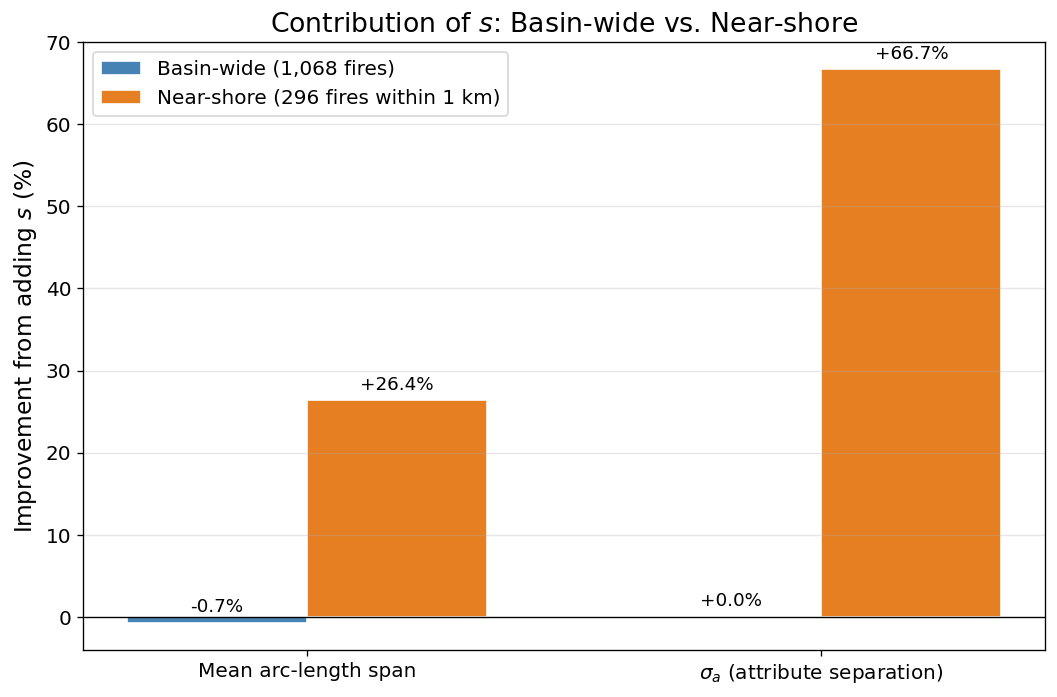

In [91]:
# Comparison bar chart: s contribution on basin-wide vs. near-shore subsets
fig, ax = plt.subplots(figsize=(9, 6))

# Data: percent contribution of s (basin-wide vs. near-shore)
metrics = ['Mean arc-length span', r'$\sigma_a$ (attribute separation)']
basin_pcts = [span_pct, sigma_pct]
near_shore_pcts = [span_pct_reopt, sigma_pct_reopt]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, basin_pcts, width, label='Basin-wide (1,068 fires)',
               color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, near_shore_pcts, width, label='Near-shore (296 fires within 1 km)',
               color='#e67e22', edgecolor='white')

# Value labels above each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:+.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=11)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Improvement from adding $s$ (%)')
ax.set_title('Contribution of $s$: Basin-wide vs. Near-shore')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

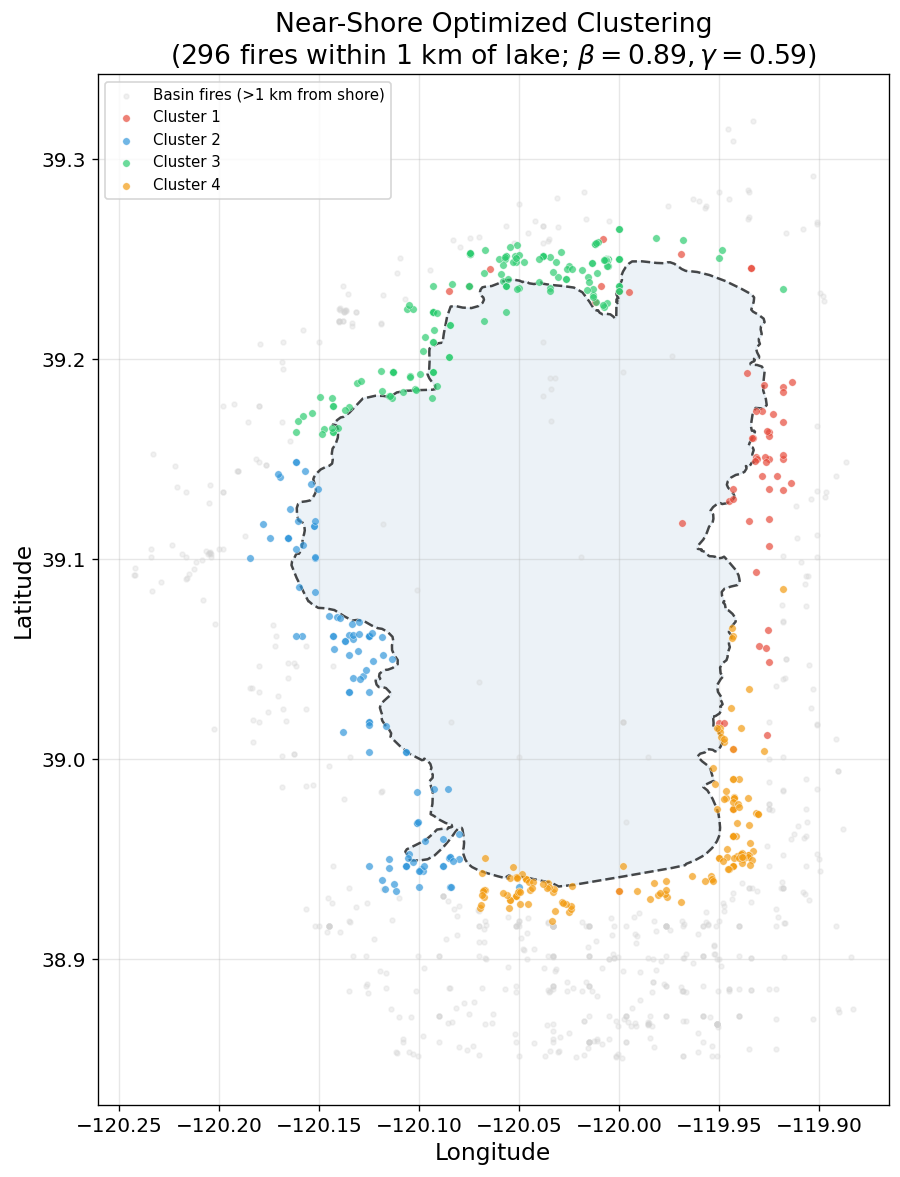

In [90]:
# Plot near-shore optimized clustering for the writeup
fig, ax = plt.subplots(figsize=(10, 10))

# Boundary first
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

# Show all basin fires faintly for context
basin_mask = ~near_mask
ax.scatter(fires['LONGITUDE'].values[basin_mask],
           fires['LATITUDE'].values[basin_mask],
           c='lightgray', s=8, alpha=0.3, zorder=2,
           label=f'Basin fires (>1 km from shore)')

# Near-shore fires colored by cluster
fires_near = fires[near_mask].reset_index(drop=True)
for i in range(k):
    mask = model_near_opt.labels_ == i
    ax.scatter(fires_near['LONGITUDE'].values[mask],
               fires_near['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=20, alpha=0.7,
               label=f'Cluster {i+1}', zorder=3, edgecolors='white', linewidth=0.3)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(r'Near-Shore Optimized Clustering' + '\n' +
             rf'(296 fires within 1 km of lake; $\beta = {opt_beta_near:.2f}, \gamma = {opt_gamma_near:.2f}$)')
ax.legend(loc='best', fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
# Build a profile table for the near-shore optimized clusters
fires_near = fires[near_mask].reset_index(drop=True)
fires_near['cluster_near_opt'] = model_near_opt.labels_

near_profile_rows = []
for c in range(k):
    cluster = fires_near[fires_near['cluster_near_opt'] == c]
    n = len(cluster)
    n_natural = int((cluster['cause_binary'] == 0).sum())
    n_human = n - n_natural
    near_profile_rows.append({
        'Cluster': c + 1,
        'n': n,
        'Centroid (lon, lat)': f'({cluster["LONGITUDE"].mean():.3f}, '
                               f'{cluster["LATITUDE"].mean():.3f})',
        'Mean fire size (acres)': cluster['FIRE_SIZE'].mean(),
        'Median fire size (acres)': cluster['FIRE_SIZE'].median(),
        '% Natural': 100 * n_natural / n,
        '% Human': 100 * n_human / n,
    })

near_profile = pd.DataFrame(near_profile_rows).set_index('Cluster')

styled_near_profile = (
    near_profile.style
    .format({
        'Mean fire size (acres)': '{:.2f}',
        'Median fire size (acres)': '{:.2f}',
        '% Natural': '{:.1f}',
        '% Human': '{:.1f}',
    })
    .set_caption('Near-Shore Optimized Clusters: Profile Summary')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: center;'},
    ])
)

styled_near_profile

,n,"Centroid (lon, lat)",Mean fire size (acres),Median fire size (acres),% Natural,% Human
Cluster,,,,,,
1,57,"(-119.947, 39.147)",108.67,0.10,59.6,40.4
2,104,"(-120.126, 39.029)",3.48,0.10,11.5,88.5
3,168,"(-120.056, 39.228)",1.80,0.10,0.0,100.0
4,139,"(-119.984, 38.956)",0.49,0.10,0.0,100.0


On the near-shore subset (296 fires within 1 km of the lake), the optimal weights are $\beta = 0.89$ and $\gamma = 0.59$ — both higher than the basin-wide optimum, reflecting that fires near the obstacle reward stronger weighting on both $s$ and attributes. Adding $s$ to this configuration improves the mean span by 26.4% (from 0.461 to 0.340) and $\sigma_a$ by 66.7% (from 0.250 to 0.417). Both metrics improve, with no trade-off between them.

These results are an order of magnitude larger than the basin-wide isolation result (2% span improvement, 17% $\sigma_a$ improvement), confirming that $s$ contributes substantially when applied to fires near the obstacle. The basin-wide result was diluted because most fires aren't close enough to the lake for $s$ to carry meaningful positional information. The improvement in $\sigma_a$ is indirect — $s$ doesn't carry attribute information directly, but tightening clusters geographically also tightens them in attribute space, since fire causes in the basin happen to correlate with location.

The implication: the algorithm's effectiveness scales with the fraction of points actually situated near the obstacle.

## 17. Saving Cluster Assignments and Summaries

We save three files for use in Notebook 04 (the interactive web map and dashboard):

- **`tahoe_fires_clustered.csv`** — the full fires DataFrame with all clustering labels attached (basin-wide and near-shore), a flag indicating which fires are in the near-shore subset, and the original attributes.
- **`cluster_summary.csv`** — per-cluster summary statistics for both views (count, centroid, mean fire size, cause breakdown, arc-length span). The dashboard's side panel populates from this.
- **`global_metrics.csv`** — view-level headline numbers (optimal weights, $\sigma_a$, $s$ contribution percentages). The dashboard's summary indicators populate from this.

In [93]:
# --- Per-fire data: enrich the fires DataFrame with all cluster labels ---

# Basin-wide cluster labels
fires['cluster_t1_oa']    = labels_t1_equal   # Tier 1 obstacle-aware (β = 1)
fires['cluster_t2_std']   = labels_t2_std     # Tier 2 standard k-Means
fires['cluster_t2_equal'] = labels_t2_equal   # Tier 2 obstacle-aware, equal weights
fires['cluster_t2_opt']   = labels_t2_opt     # Tier 2 obstacle-aware, optimized

# Near-shore subset flag and labels
# (Fires not in the near-shore subset get NaN for the near-shore cluster ID)
fires['near_shore_1km'] = near_mask
fires['cluster_near_opt'] = np.nan
fires.loc[near_mask, 'cluster_near_opt'] = model_near_opt.labels_

# Convert near-shore cluster ID to nullable integer for cleaner output
fires['cluster_near_opt'] = fires['cluster_near_opt'].astype('Int64')

# Save the enriched fires DataFrame
processed_dir = Path('../data/processed')
fires_path = processed_dir / 'tahoe_fires_clustered.csv'
fires.to_csv(fires_path, index=False)
print(f'Saved {len(fires)} clustered fires to {fires_path}')


# --- Per-cluster summary data: basin-wide and near-shore profiles ---

def build_cluster_summary(df, label_col, view_name, k):
    """Build a per-cluster summary DataFrame for use in the dashboard."""
    rows = []
    for c in range(k):
        cluster = df[df[label_col] == c]
        n = len(cluster)
        if n == 0:
            continue
        spans = arc_length_span(cluster['s_param'].values)
        n_natural = int((cluster['cause_binary'] == 0).sum())
        rows.append({
            'view': view_name,
            'cluster_id': c,
            'cluster_label': c + 1,  # 1-based for display
            'n': n,
            'centroid_lon': cluster['LONGITUDE'].mean(),
            'centroid_lat': cluster['LATITUDE'].mean(),
            'mean_fire_size': cluster['FIRE_SIZE'].mean(),
            'median_fire_size': cluster['FIRE_SIZE'].median(),
            'pct_natural': 100 * n_natural / n,
            'pct_human': 100 * (n - n_natural) / n,
            'cluster_span': spans,
        })
    return pd.DataFrame(rows)


basin_summary = build_cluster_summary(
    fires, 'cluster_t2_opt', 'basin', k
)
near_summary = build_cluster_summary(
    fires[near_mask], 'cluster_near_opt', 'near_shore', k
)
cluster_summary = pd.concat([basin_summary, near_summary], ignore_index=True)

summary_path = processed_dir / 'cluster_summary.csv'
cluster_summary.to_csv(summary_path, index=False)
print(f'Saved {len(cluster_summary)} cluster summaries to {summary_path}')


# --- Global metrics: view-level numbers for dashboard indicators ---

global_metrics = pd.DataFrame([
    {
        'view': 'basin',
        'n_fires': len(fires),
        'optimal_beta': opt_beta_t2,
        'optimal_gamma': opt_gamma_t2,
        'mean_arc_span': comparison_t2.loc['Obstacle-Aware (Optimized)', 'Mean arc-length span'],
        'sigma_a': sigma_t2_opt,
        's_contribution_span_pct': span_pct,
        's_contribution_sigma_pct': sigma_pct,
    },
    {
        'view': 'near_shore',
        'n_fires': int(near_mask.sum()),
        'optimal_beta': opt_beta_near,
        'optimal_gamma': opt_gamma_near,
        'mean_arc_span': np.mean(spans_near_opt),
        'sigma_a': sigma_near_opt,
        's_contribution_span_pct': span_pct_reopt,
        's_contribution_sigma_pct': sigma_pct_reopt,
    },
])

metrics_path = processed_dir / 'global_metrics.csv'
global_metrics.to_csv(metrics_path, index=False)
print(f'Saved global metrics to {metrics_path}')
print()
print('Files for Notebook 04:')
print(f'  {fires_path.name}      ({len(fires)} fires, all clustering labels)')
print(f'  {summary_path.name}      ({len(cluster_summary)} cluster summaries)')
print(f'  {metrics_path.name}        (2 view-level metric rows)')

Saved 1068 clustered fires to ..\data\processed\tahoe_fires_clustered.csv
Saved 8 cluster summaries to ..\data\processed\cluster_summary.csv
Saved global metrics to ..\data\processed\global_metrics.csv

Files for Notebook 04:
  tahoe_fires_clustered.csv      (1068 fires, all clustering labels)
  cluster_summary.csv      (8 cluster summaries)
  global_metrics.csv        (2 view-level metric rows)


## 18. Summary

In this notebook, we:

1. **Loaded wildfire data** for the Tahoe Regional Planning Agency (TRPA) basin from the FPA FOD database, restricting to fires within the bi-state planning unit used by TRPA, the Tahoe Fire & Fuels Team, and the seven local fire protection districts.
2. **Engineered features** for clustering, including the arc-length parameter $s$ from Notebook 02, log-scaled fire size, and a binary cause encoding.
3. **Ran a two-tier comparison** to isolate the contribution of each component of the obstacle-aware framework, with three additional diagnostics in Tier 2 to characterize when and why each component does meaningful work.
4. **Saved cluster assignments** to a CSV for use in the web map in Notebook 04.

### Tier 1 Findings

In the spatial-only setting, the obstacle-aware algorithm produced a slightly tighter clustering than standard k-Means (mean arc-length span dropped from 0.265 to 0.247, a 7% reduction). Most of this improvement came from a single cluster, with the rest of the partition nearly unchanged. A sensitivity check confirmed that the choice of $\beta$ does not meaningfully change the clustering on this dataset — fires across the basin are diffuse enough that geographic distance and arc-length distance largely agree on cluster assignments.

### Tier 2 Findings

Adding fire size and cause as attribute features changed the picture substantially. The optimized obstacle-aware method ($\beta = 0.47, \gamma = 0.39$) outperformed both standard k-Means and equal-weight obstacle-aware on both metrics: mean arc-length span dropped 26% (0.474 → 0.351) while attribute separation $\sigma_a$ more than doubled (0.25 → 0.58).

The equal-weight result was actually *worse* than standard k-Means on geographic coherence — with $\gamma = 1$ pulling hard on attributes, the algorithm sacrificed spatial compactness without gaining much attribute separation. The optimization corrected this by lowering $\beta$ and $\gamma$ relative to $\alpha$, letting geography lead while still using attributes to drive meaningful behavioral separation between clusters.

The final clusters represent distinct fire regimes around the basin: a dominant south-basin human-caused cluster, a small but distinctive lightning-prone cluster with much larger average fire size, and two additional human-caused clusters in the west and north basin. This is the kind of structure the multi-domain framework was designed to surface.

### Diagnostics

Three follow-up experiments characterized where the framework's value comes from. A baseline check showed that geographic clustering alone produces $\sigma_a = 0.083$ — close to the minimum non-zero value — so the optimized method's $\sigma_a$ of 0.583 reflects deliberate algorithmic choice rather than incidental correlation. An isolation experiment held $\gamma$ at its optimum and toggled $s$ on and off, showing that $s$ improves mean span by only 2% and $\sigma_a$ by 17% on the full basin. But when the analysis was restricted to fires within 1 km of the lake (where $s$ carries the most positional information) and weights were re-optimized, $s$'s contribution jumped to 26% on span and 67% on $\sigma_a$ — an order of magnitude larger. 

Together, these diagnostics give a calibrated picture: the multi-domain framework provides real improvement over standard k-Means, the optimization step is necessary (equal weights underperforms), and the arc-length parameter's value depends on how much of the dataset actually sits near the obstacle.

### What's Next

Notebook 04 builds an interactive ArcGIS dashboard that lets fire planners and other stakeholders explore the optimized clustering results geographically, with a toggle between the basin-wide and near-shore views and side-panel summaries that update as the user clicks individual clusters.

### Key Files Produced

| File | Description |
|------|-------------|
| `data/processed/tahoe_fires_processed.csv` | Cleaned fire data with arc-length projection and engineered features (no cluster labels) |
| `data/processed/tahoe_fires_clustered.csv` | Same as above, plus cluster-label columns for all Tier 1 and Tier 2 methods, the near-shore optimized labels, and a flag for the near-shore subset |
| `data/processed/cluster_summary.csv` | Per-cluster summary statistics (count, centroid, mean fire size, cause breakdown, arc-length span) for both basin-wide and near-shore optimized clusterings |
| `data/processed/global_metrics.csv` | View-level headline numbers (optimal weights, $\sigma_a$, $s$ contribution percentages) for the dashboard's summary indicators |